In [426]:
import yaml
import logging
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Meiryo'

logger = logging.getLogger(__name__)

In [427]:
df = pd.read_csv("data/shopping_behavior_updated.csv")

In [428]:
def load_encoding_config(path: Path) -> dict:
    """エンコーディング設定ファイルを読み込む

    Args:
        path (Path): YAMLファイルへのパス

    Returns:
        dict: エンコーディングマッピング
    """
    with path.open("r", encoding="utf-8") as f:
        config = yaml.safe_load(f)

    return config["encoding"]

def counts_and_ratio_of_column(df: pd.DataFrame, column: str) -> pd.DataFrame:
    return df[column].value_counts().to_frame(name="件数").assign(割合=df[column].value_counts(normalize=True) * 100)

def encode_columns(df: pd.DataFrame, encoding_config: Dict[str, Dict[str, int]]) -> pd.DataFrame:
    """指定されたエンコーディング設定に基づき、DataFrameの列を数値エンコードする。

    Args:
        df (pd.DataFrame): エンコード対象のデータフレーム。
        encoding_config (Dict[str, Dict[str, int]]): カラム名と、そのカラムに適用するエンコードマッピング。

    Returns:
        pd.DataFrame: エンコード後のデータフレーム。

    Raises:
        KeyError: 指定されたカラムがDataFrameに存在しない場合。
        ValueError: エンコード後にNaNが発生した場合（未対応の値が存在する場合）。

    Example:
        df = encode_columns(df, encoding_config)
    """
    df_encoded = df.copy()
    
    for column, mapping in encoding_config.items():
        if column not in df_encoded.columns:
            raise KeyError(f"指定されたカラム {column} がDataFrameに存在しません。")

        logger.info(f"カラム {column} をエンコード中。マッピング: {mapping}")
        df_encoded[column] = df_encoded[column].map(mapping)

        if df_encoded[column].isnull().any():
            raise ValueError(f"カラム {column} にエンコードできなかった値が存在します。")

    return df_encoded


In [429]:
config_path = Path("config/config.yaml")
encoding_config = load_encoding_config(config_path)

### 列名(日本語訳)
| 番号 | カラム名                    | 説明                          |
|------|-----------------------------|-------------------------------|
| 1    | Age                         | 年齢                          |
| 2    | Gender                      | 性別                          |
| 3    | Item Purchased              | 購入したアイテム              |
| 4    | Category                    | カテゴリ                      |
| 5    | Purchase Amount (USD)       | 購入金額（USD）               |
| 6    | Location                    | 位置（地域）                  |
| 7    | Size                        | サイズ                        |
| 8    | Color                       | 色                             |
| 9    | Season                      | 季節                          |
| 10   | Review Rating               | レビュー評価                  |
| 11   | Subscription Status         | サブスクリプションステータス  |
| 12   | Shipping Type               | 配送タイプ                    |
| 13   | Discount Applied            | 割引適用                      |
| 14   | Promo Code Used             | プロモコード使用             |
| 15   | Previous Purchases          | 過去の購入回数                |
| 16   | Payment Method              | 支払い方法                    |
| 17   | Frequency of Purchases      | 購入頻度                      |


### データの概要

In [430]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3900 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [431]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3900.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.749949,25.351538
std,1125.977353,15.207589,23.685392,0.716223,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.700000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [432]:
df.isna().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [433]:
labels = {}
for column in df.columns:
    labels[column] = df[column].unique()

### 年齢の概要

In [434]:
df["Age"].describe()

count    3900.000000
mean       44.068462
std        15.207589
min        18.000000
25%        31.000000
50%        44.000000
75%        57.000000
max        70.000000
Name: Age, dtype: float64

In [435]:
df["AgeGroup"] =  pd.cut(df["Age"], bins=[17, 29, 39, 49, 59, 70], 
                        labels=["18-29", "30-39", "40-49", "50-59", "60-70"])
print(counts_and_ratio_of_column(df, "AgeGroup"))

           件数         割合
AgeGroup                
18-29     878  22.512821
60-70     788  20.205128
50-59     771  19.769231
40-49     739  18.948718
30-39     724  18.564103


### 性別

In [436]:
print(counts_and_ratio_of_column(df, "Gender"))

          件数    割合
Gender            
Male    2652  68.0
Female  1248  32.0


### 購買アイテムカテゴリ

In [437]:
# Item Purchased列は、カテゴリで代表するため、ドロップ
df = df.drop("Item Purchased", axis=True)

In [438]:
print(counts_and_ratio_of_column(df, "Category"))

               件数         割合
Category                    
Clothing     1737  44.538462
Accessories  1240  31.794872
Footwear      599  15.358974
Outerwear     324   8.307692


### 購買金額
| ラベル       | 金額の範囲（USD） |
| --------- | ------------------ |
| Very Low  | \$20.00 ～ \$36.00  |
| Low       | \$36.00 ～ \$52.00  |
| Medium    | \$52.00 ～ \$68.00  |
| High      | \$68.00 ～ \$84.00  |
| Very High | \$84.00 ～ \$100.00 |



In [439]:
df["Purchase Amount (USD)"].describe()

count    3900.000000
mean       59.764359
std        23.685392
min        20.000000
25%        39.000000
50%        60.000000
75%        81.000000
max       100.000000
Name: Purchase Amount (USD), dtype: float64

In [440]:
df["PurchaseAmountGroup"] = pd.cut(df["Purchase Amount (USD)"], bins=5,
                                   labels=["Very Low", "Low", "Medium", "High", "Very High"])
# df["PurchaseAmountGroup"] = pd.cut(df["Purchase Amount (USD)"], bins=[0, 20, 40, 60, 80, 99, 100],
#                                    labels=["Very Low", "Low", "Medium", "High", "Very High", "Over"])
print(counts_and_ratio_of_column(df, "PurchaseAmountGroup"))

                      件数         割合
PurchaseAmountGroup                
Very Low             869  22.282051
Very High            779  19.974359
Medium               756  19.384615
Low                  750  19.230769
High                 746  19.128205


In [441]:
df.groupby('Category')['Purchase Amount (USD)'].mean()

Category
Accessories    59.838710
Clothing       60.025331
Footwear       60.255426
Outerwear      57.172840
Name: Purchase Amount (USD), dtype: float64

### 地域

In [442]:
df["Location"].describe()

count        3900
unique         50
top       Montana
freq           96
Name: Location, dtype: object

In [443]:
df["Location"].unique()

array(['Kentucky', 'Maine', 'Massachusetts', 'Rhode Island', 'Oregon',
       'Wyoming', 'Montana', 'Louisiana', 'West Virginia', 'Missouri',
       'Arkansas', 'Hawaii', 'Delaware', 'New Hampshire', 'New York',
       'Alabama', 'Mississippi', 'North Carolina', 'California',
       'Oklahoma', 'Florida', 'Texas', 'Nevada', 'Kansas', 'Colorado',
       'North Dakota', 'Illinois', 'Indiana', 'Arizona', 'Alaska',
       'Tennessee', 'Ohio', 'New Jersey', 'Maryland', 'Vermont',
       'New Mexico', 'South Carolina', 'Idaho', 'Pennsylvania',
       'Connecticut', 'Utah', 'Virginia', 'Georgia', 'Nebraska', 'Iowa',
       'South Dakota', 'Minnesota', 'Washington', 'Wisconsin', 'Michigan'],
      dtype=object)

### 地域ごとに分類

* **西部（West）**
  例：California, Nevada, Oregon, Washington, Idaho, Montana, Alaska, Hawaii, Colorado, Utah, Wyoming

* **南部（South）**
  例：Texas, Florida, Georgia, Louisiana, Alabama, Kentucky, Tennessee, Arkansas, Mississippi, South Carolina, North Carolina, Virginia, Oklahoma

* **中西部（Midwest）**
  例：Illinois, Iowa, Minnesota, Michigan, Ohio, Wisconsin, Indiana, Missouri, Nebraska, North Dakota, South Dakota, Kansas

* **北東部（Northeast）**
  例：New York, Pennsylvania, New Jersey, Massachusetts, Connecticut, Rhode Island, Maine, New Hampshire, Vermont, Delaware, Maryland

* **その他（Others）**
  特に該当しない場合や、地理的に特殊な州を分類します（例：Alaska, Hawaii）


### 課題
ファッションに関するデータなので、気候を考慮した分類の方がよい。
一旦は地理的なカテゴライズで分析をすすめる

In [444]:
# 各州を地域ごとに分類
location_map = {
    'Montana': 'West', 'California': 'West', 'Idaho': 'West', 'Illinois': 'Midwest',
    'Alabama': 'South', 'Minnesota': 'Midwest', 'New York': 'Northeast', 'Nevada': 'West',
    'Nebraska': 'Midwest', 'Delaware': 'Northeast', 'Maryland': 'Northeast', 'Vermont': 'Northeast',
    'Louisiana': 'South', 'North Dakota': 'Midwest', 'West Virginia': 'South', 'Missouri': 'Midwest',
    'New Mexico': 'West', 'Mississippi': 'South', 'Kentucky': 'South', 'Arkansas': 'South',
    'Georgia': 'South', 'Indiana': 'Midwest', 'Connecticut': 'Northeast', 'North Carolina': 'South',
    'Maine': 'Northeast', 'Ohio': 'Midwest', 'Virginia': 'South', 'Texas': 'South', 'Tennessee': 'South',
    'South Carolina': 'South', 'Oklahoma': 'South', 'Wisconsin': 'Midwest', 'Colorado': 'West',
    'Oregon': 'West', 'Pennsylvania': 'Northeast', 'Michigan': 'Midwest', 'Washington': 'West',
    'Alaska': 'Others', 'Massachusetts': 'Northeast', 'Utah': 'West', 'Wyoming': 'West',
    'New Hampshire': 'Northeast', 'South Dakota': 'Midwest', 'Iowa': 'Midwest', 'Florida': 'South',
    'New Jersey': 'Northeast', 'Arizona': 'West', 'Hawaii': 'Others', 'Rhode Island': 'Northeast',
    'Kansas': 'Midwest'
}

# Region列を追加して地域分類を適用
df['LocationGroup'] = df["Location"].map(location_map)
print(counts_and_ratio_of_column(df, "LocationGroup"))


                 件数         割合
LocationGroup                 
South          1099  28.179487
Midwest         937  24.025641
West            881  22.589744
Northeast       846  21.692308
Others          137   3.512821


### サイズ

In [445]:
print(counts_and_ratio_of_column(df, "Size"))

        件数    割合
Size            
M     1755  45.0
L     1053  27.0
S      663  17.0
XL     429  11.0


### 色

In [446]:
df["Color"].describe()

count      3900
unique       25
top       Olive
freq        177
Name: Color, dtype: object

In [447]:
df["Color"].unique()

array(['Gray', 'Maroon', 'Turquoise', 'White', 'Charcoal', 'Silver',
       'Pink', 'Purple', 'Olive', 'Gold', 'Violet', 'Teal', 'Lavender',
       'Black', 'Green', 'Peach', 'Red', 'Cyan', 'Brown', 'Beige',
       'Orange', 'Indigo', 'Yellow', 'Magenta', 'Blue'], dtype=object)

### 色分類

#### 1. **ベーシックカラー**

* Black（167）
* White（142）
* Gray（159）
* Charcoal（153）
* Beige（147）
* Brown（141）

#### 2. **アースカラー**

* Olive（177）
* Green（169）

#### 3. **ビビッドカラー**

* Red（148）
* Yellow（174）
* Blue（152）
* Orange（154）
* Magenta（152）
* Cyan（166）
* Turquoise（145）

#### 4. **ペール・パステルカラー**

* Pink（153）
* Peach（149）
* Lavender（147）

#### 5. **ダークカラー**

* Maroon（158）
* Indigo（147）
* Violet（166）
* Purple（151）

#### 6. **メタリック・アクセントカラー**

* Gold（138）
* Silver（173）


In [448]:
color_category_map = {
    # ベーシックカラー
    'Black': 'Basic',
    'White': 'Basic',
    'Gray': 'Basic',
    'Charcoal': 'Basic',
    'Beige': 'Basic',
    'Brown': 'Basic',

    # アースカラー
    'Olive': 'Earth',
    'Green': 'Earth',

    # ビビッドカラー
    'Red': 'Vivid',
    'Yellow': 'Vivid',
    'Blue': 'Vivid',
    'Orange': 'Vivid',
    'Magenta': 'Vivid',
    'Cyan': 'Vivid',
    'Turquoise': 'Vivid',

    # ペール・パステルカラー
    'Pink': 'Pastel',
    'Peach': 'Pastel',
    'Lavender': 'Pastel',

    # ダークカラー
    'Maroon': 'Dark',
    'Indigo': 'Dark',
    'Violet': 'Dark',
    'Purple': 'Dark',

    # メタリック・アクセントカラー
    'Gold': 'Metallic',
    'Silver': 'Metallic'
}


df["ColorGroup"] = df["Color"].map(color_category_map)
print(counts_and_ratio_of_column(df, "ColorGroup"))

              件数         割合
ColorGroup                 
Vivid       1091  29.265021
Basic        909  24.383047
Dark         622  16.684549
Pastel       449  12.043991
Earth        346   9.281116
Metallic     311   8.342275


### 季節

In [449]:
print(counts_and_ratio_of_column(df, "Season"))

         件数         割合
Season                
Spring  999  25.615385
Fall    975  25.000000
Winter  971  24.897436
Summer  955  24.487179


### レビュー評価

In [450]:
df["Review Rating"].describe()

count    3900.000000
mean        3.749949
std         0.716223
min         2.500000
25%         3.100000
50%         3.700000
75%         4.400000
max         5.000000
Name: Review Rating, dtype: float64

### レビュー評価のカテゴリ分類：

| カテゴリ          | 範囲        | 説明                 |
| ------------- | --------- | ------------------ |
| **Very Low**  | 2.5 以下    | 非常に低評価（不満層）        |
| **Low**       | 2.6 ～ 3.0 | やや低評価（懸念あり）        |
| **Medium**    | 3.1 ～ 3.9 | 中間評価（普通〜可もなく不可もなく） |
| **High**      | 4.0 ～ 4.4 | 高評価（満足）            |
| **Very High** | 4.5 以上    | 非常に高評価（大満足）        |


In [451]:
def categorize_rating(rating: float) -> str:
    """レビュー評価に応じてカテゴリを返す。

    Args:
        rating (float): レビュー評価（例: 3.5）

    Returns:
        str: カテゴリ（Very Low, Low, Medium, High, Very High）

    Example:
        >>> categorize_rating(4.2)
        'High'
    """
    if rating <= 2.5:
        return "Very Low"
    elif rating <= 3.0:
        return "Low"
    elif rating <= 3.9:
        return "Medium"
    elif rating <= 4.4:
        return "High"
    else:
        return "Very High"

df["ReviewRatingGroup"] = df["Review Rating"].apply(categorize_rating)
print(counts_and_ratio_of_column(df, "ReviewRatingGroup"))

                     件数         割合
ReviewRatingGroup                 
Medium             1409  36.128205
Very High           839  21.512821
High                805  20.641026
Low                 781  20.025641
Very Low             66   1.692308


### サブスクリプション


In [452]:
# df = df["Subscription Status"].apply({"Yes": 1, "No":0})
print(counts_and_ratio_of_column(df, "Subscription Status"))

                       件数    割合
Subscription Status            
No                   2847  73.0
Yes                  1053  27.0


### 配送料
| Shipping Type  |  備考                         |
| -------------- |  -------------------------- |
| Free Shipping  |  明示的に無料                     |
| Store Pickup   |  店頭受取は一般的に無料                |
| Standard       |  通常配送でも料金が発生する想定（キャンペーン等除く） |
| 2-Day Shipping |  時間指定で有料の可能性高               |
| Express        |  速達扱いで有料                    |
| Next Day Air   |  翌日配送で確実に有料                 |


In [453]:
print(counts_and_ratio_of_column(df, "Shipping Type"))

                 件数         割合
Shipping Type                 
Free Shipping   675  17.307692
Standard        654  16.769231
Store Pickup    650  16.666667
Next Day Air    648  16.615385
Express         646  16.564103
2-Day Shipping  627  16.076923


### 割引の適用

In [454]:
print(counts_and_ratio_of_column(df, "Discount Applied"))

                    件数    割合
Discount Applied            
No                2223  57.0
Yes               1677  43.0


In [ ]:
df = df.drop("Promo Code Used", axis=True)

,Customer ID,Age,Gender,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,...,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases,AgeGroup,PurchaseAmountGroup,LocationGroup,ColorGroup,ReviewRatingGroup
0,1,55,Male,Clothing,53,Kentucky,L,Gray,Winter,3.1,...,Express,Yes,14,Venmo,Fortnightly,50-59,Medium,South,Basic,Medium
1,2,19,Male,Clothing,64,Maine,L,Maroon,Winter,3.1,...,Express,Yes,2,Cash,Fortnightly,18-29,Medium,Northeast,Dark,Medium
2,3,50,Male,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,...,Free Shipping,Yes,23,Credit Card,Weekly,50-59,High,Northeast,Dark,Medium
3,4,21,Male,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,...,Next Day Air,Yes,49,PayPal,Weekly,18-29,Very High,Northeast,Dark,Medium
4,5,45,Male,Clothing,49,Oregon,M,Turquoise,Spring,2.7,...,Free Shipping,Yes,31,PayPal,Annually,40-49,Low,West,Vivid,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3895,3896,40,Female,Clothing,28,Virginia,L,Turquoise,Summer,4.2,...,2-Day Shipping,No,32,Venmo,Weekly,40-49,Very Low,South,Vivid,High
3896,3897,52,Female,Accessories,49,Iowa,L,White,Spring,4.5,...,Store Pickup,No,41,Bank Transfer,Bi-Weekly,50-59,Low,Midwest,Basic,Very High
3897,3898,46,Female,Accessories,33,New Jersey,L,Green,Spring,2.9,...,Standard,No,24,Venmo,Quarterly,40-49,Very Low,Northeast,Earth,Low
3898,3899,44,Female,Footwear,77,Minnesota,S,Brown,Summer,3.8,...,Express,No,24,Venmo,Weekly,40-49,High,Midwest,Basic,Medium


### 過去の購買履歴
| Previous Purchase （回数）  | 分類 |
| -------------- | -- |
| 0 - 9  | Very Low | 
| 10 - 19 | Low |
| 20 - 29 | Medium |
| 30 - 39 | High |
| 40 - 50 | Very High |

In [475]:
df["Previous Purchases"].describe()

count    3900.000000
mean       25.351538
std        14.447125
min         1.000000
25%        13.000000
50%        25.000000
75%        38.000000
max        50.000000
Name: Previous Purchases, dtype: float64

In [456]:

df["PreviousPurchasesGroup"] = pd.cut(df["Previous Purchases"], bins=[0, 9, 19, 29, 39, 50], 
                                   labels=["Very Low", "Low", "Medium", "High", "Very High"])
df["PreviousPurchasesGroup"].value_counts()

PreviousPurchasesGroup
Very High    847
Medium       791
High         784
Low          770
Very Low     708
Name: count, dtype: int64

In [457]:
df["AgeGroup"].value_counts()

AgeGroup
18-29    878
60-70    788
50-59    771
40-49    739
30-39    724
Name: count, dtype: int64

<Axes: xlabel='AgeGroup'>

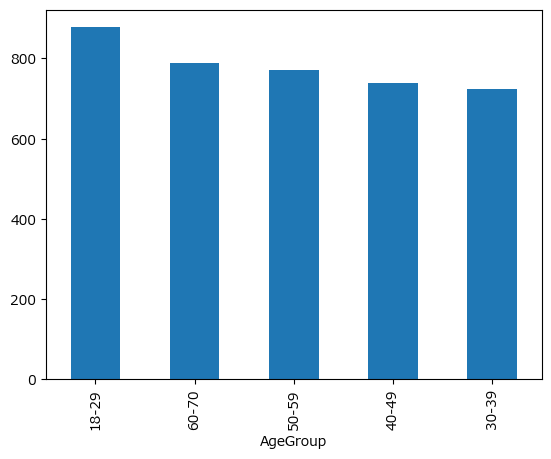

In [458]:
df["AgeGroup"].value_counts().plot(kind="bar")

<Axes: xlabel='PurchaseAmountGroup'>

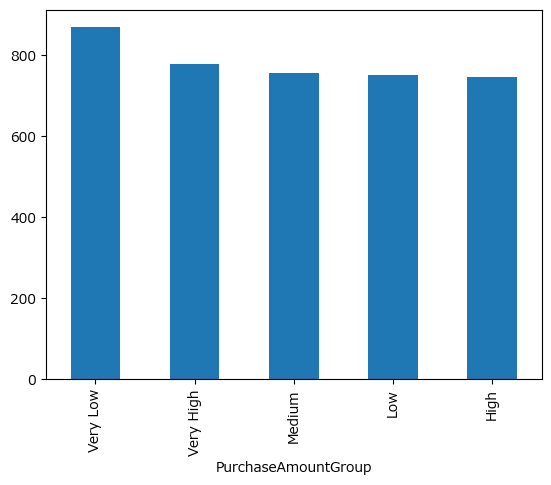

In [459]:
df["PurchaseAmountGroup"].value_counts().plot(kind="bar")

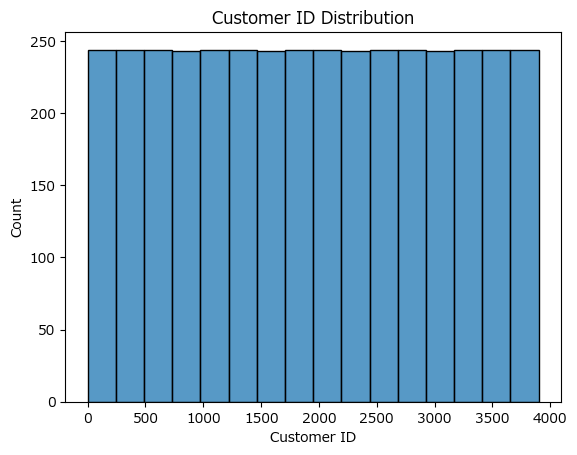

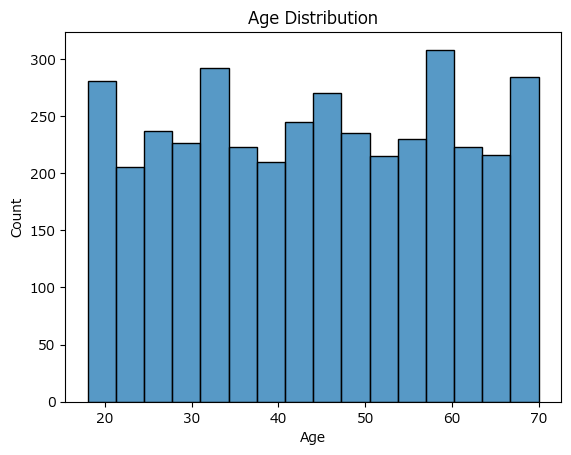

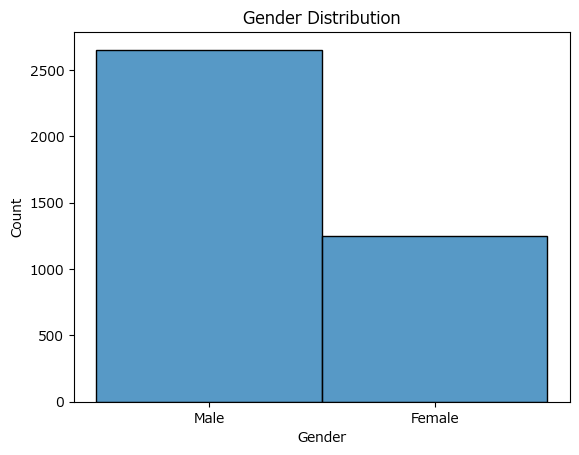

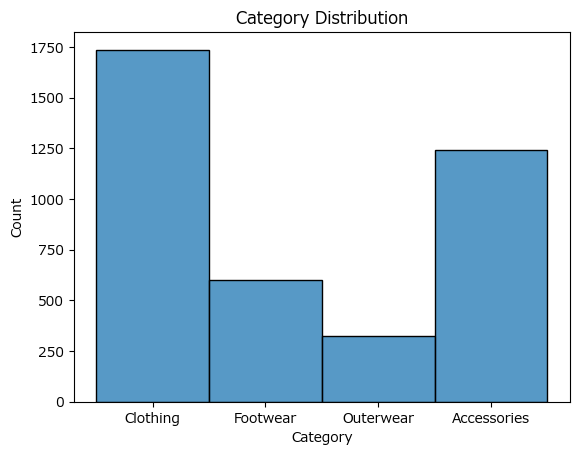

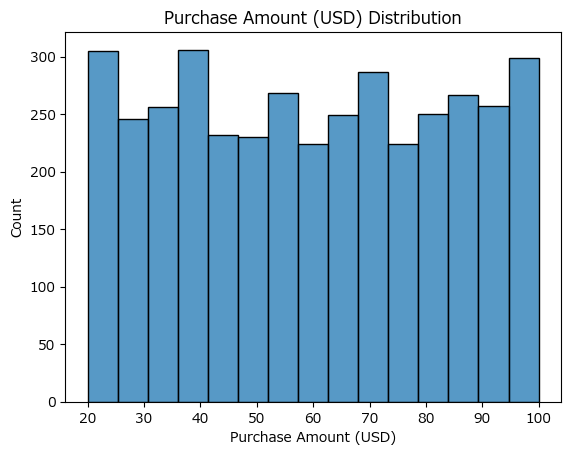

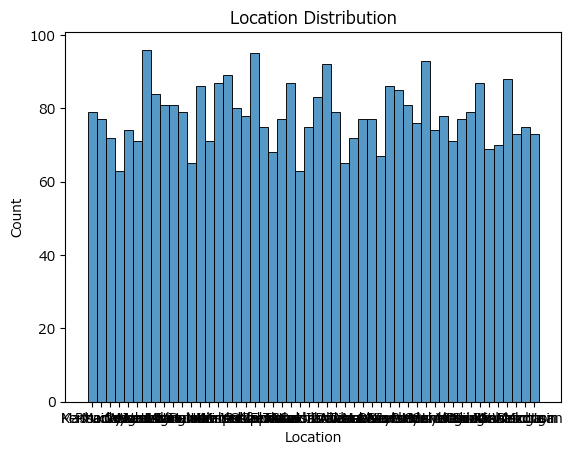

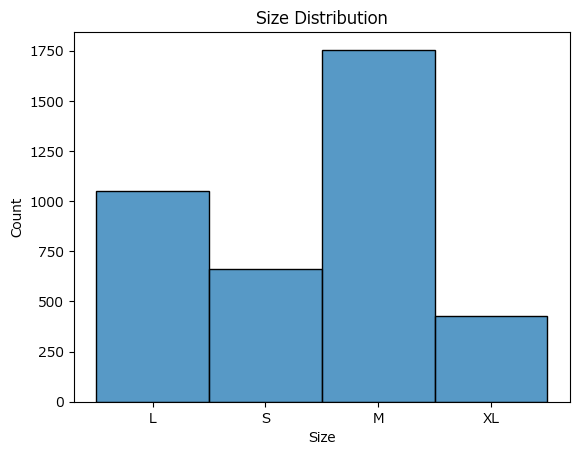

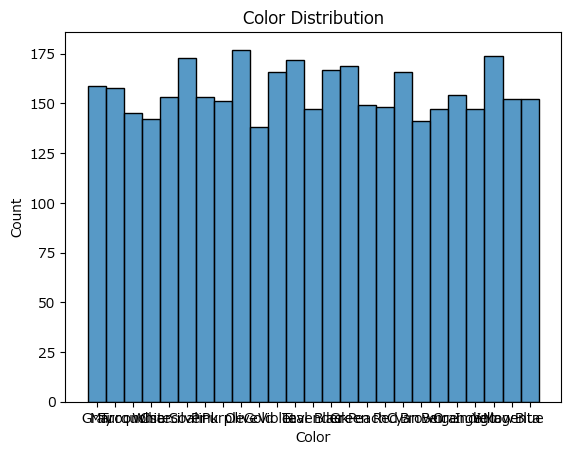

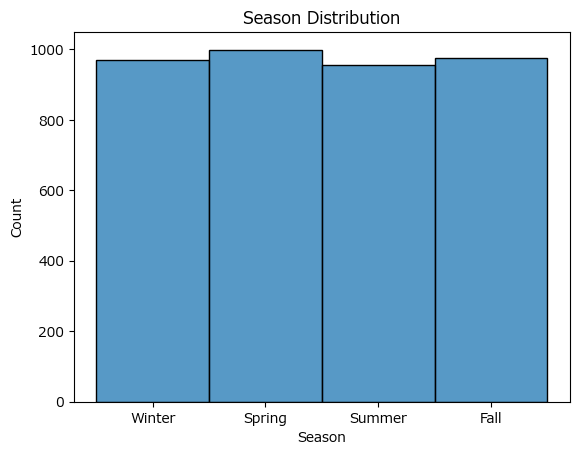

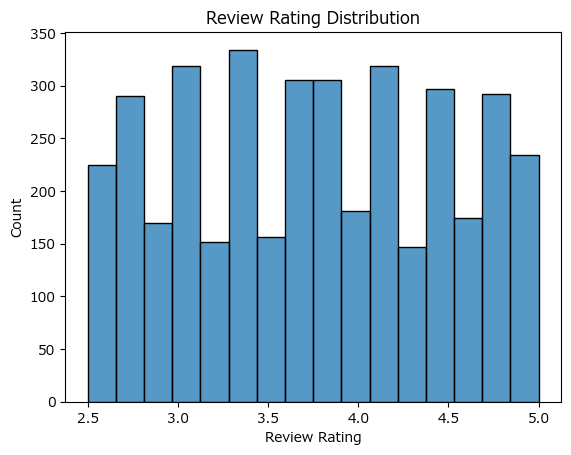

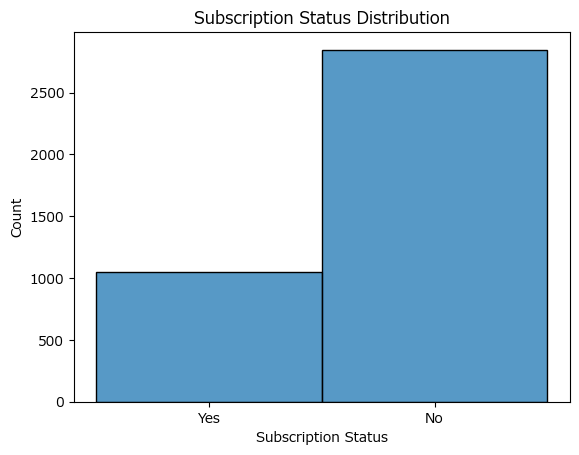

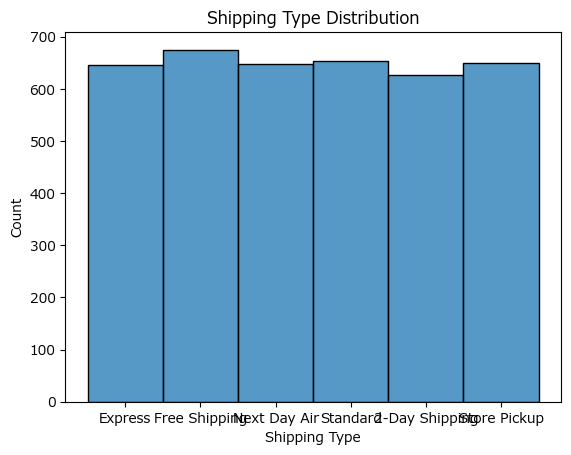

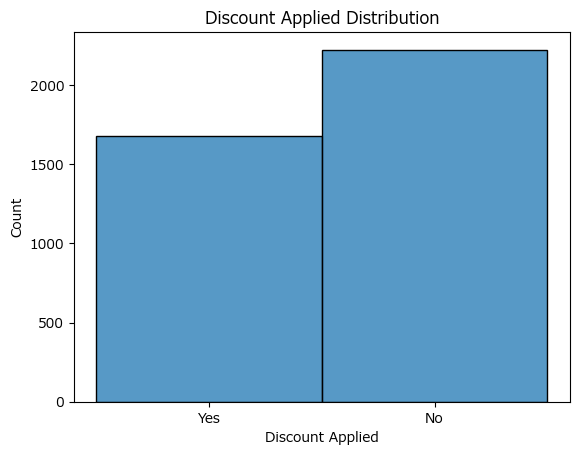

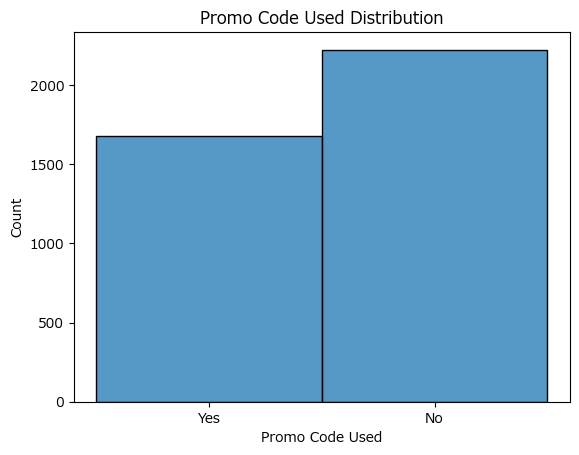

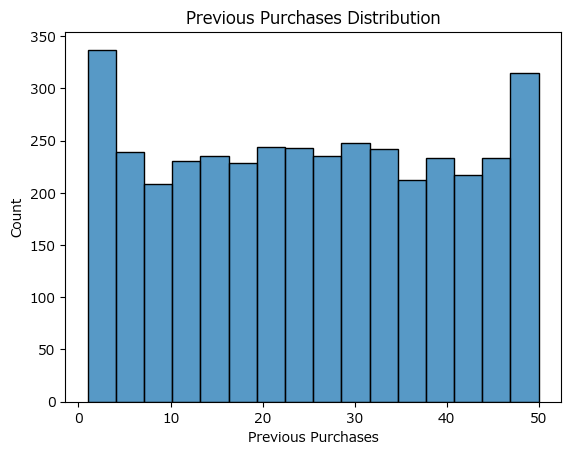

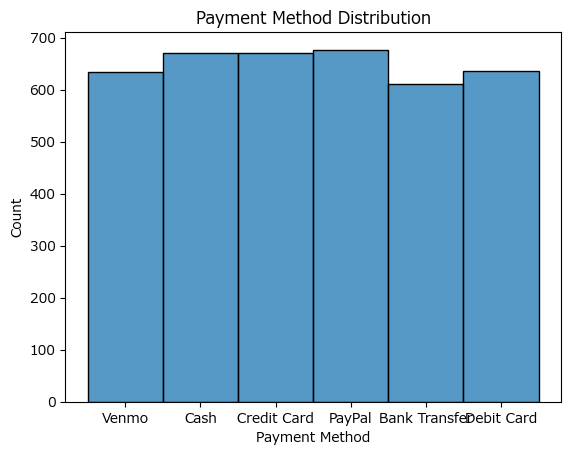

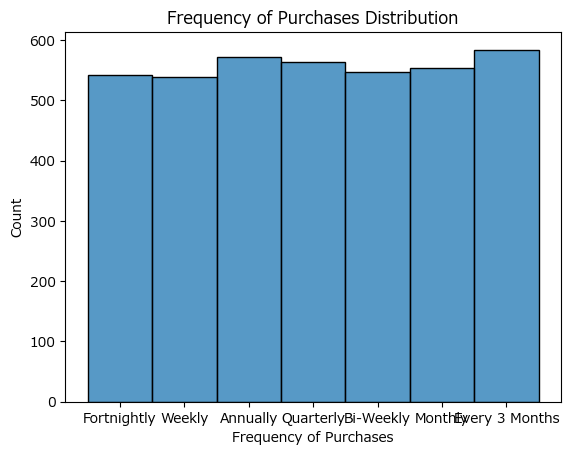

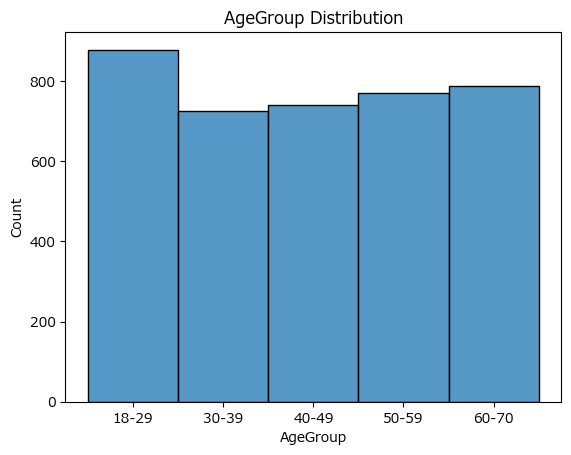

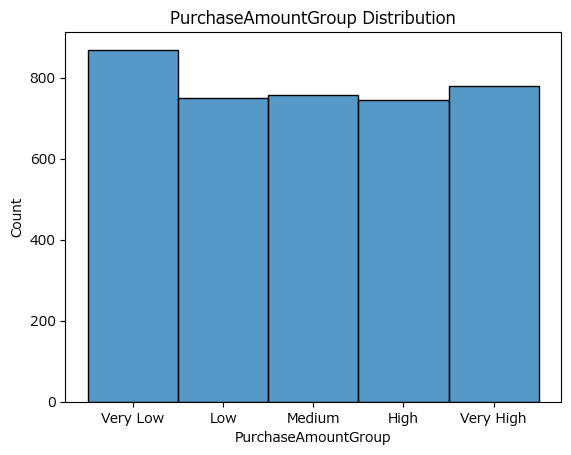

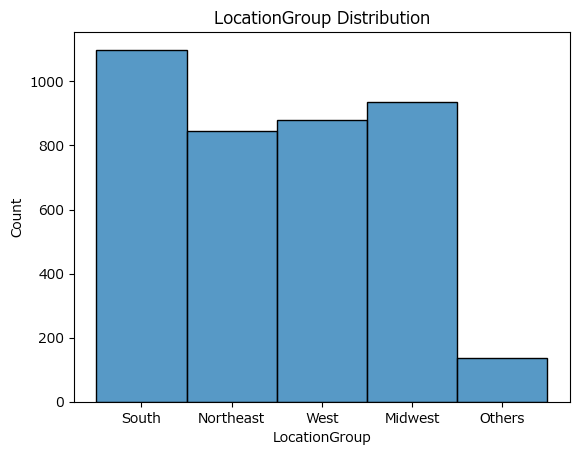

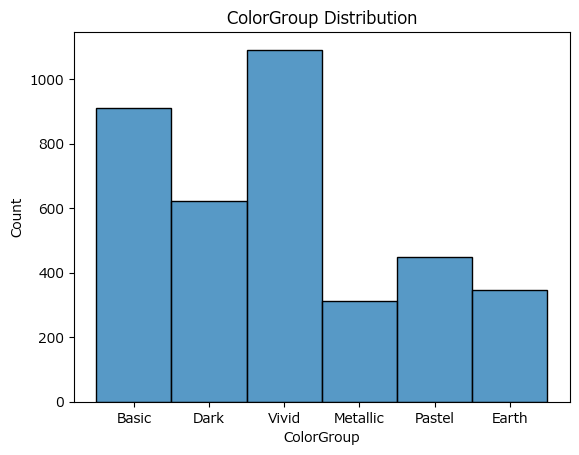

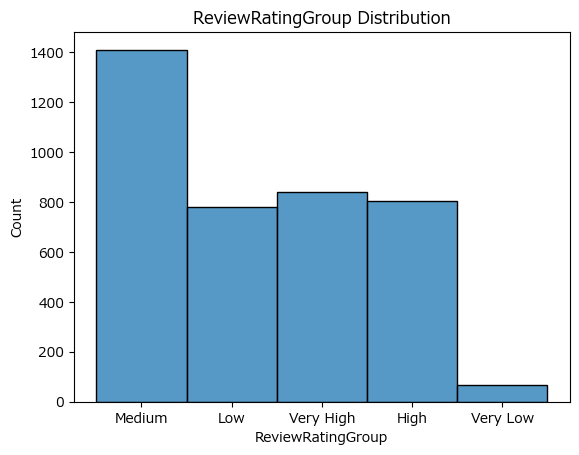

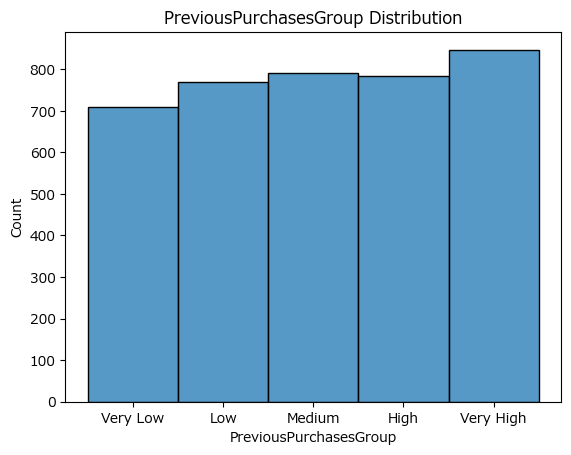

In [460]:
for column in df.columns:
    sns.histplot(df[column])
    plt.title(f'{column} Distribution')
    plt.show()

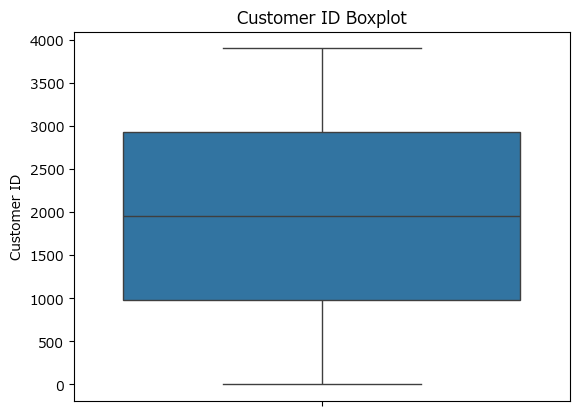

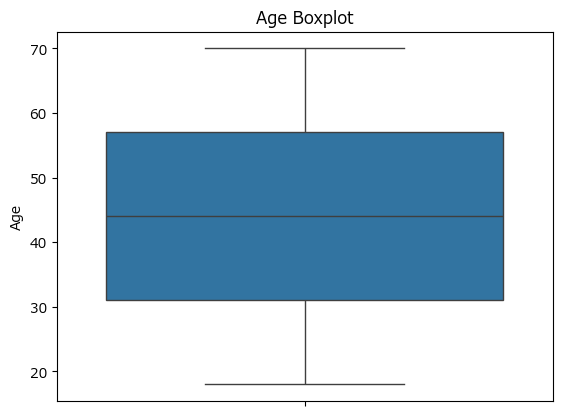

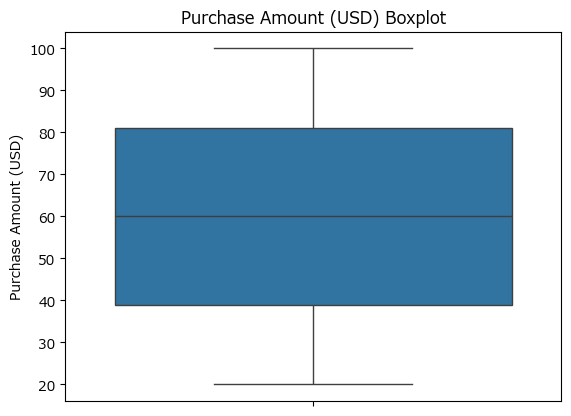

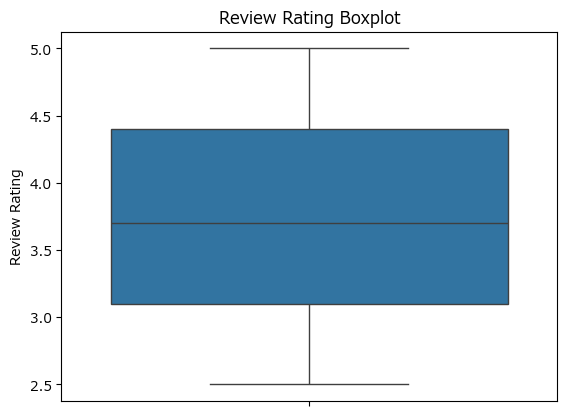

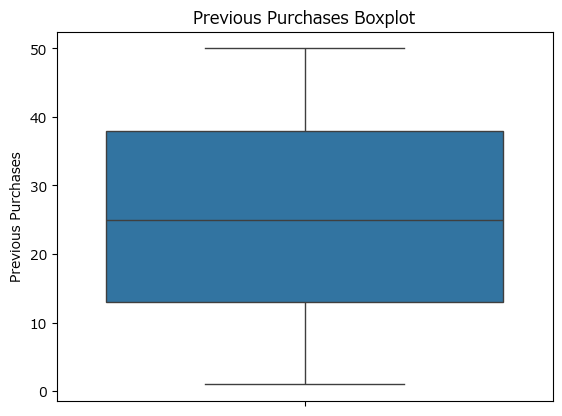

In [461]:
for column in df.select_dtypes(include=['int64', 'float64']).columns:
    sns.boxplot(y=df[column])
    plt.title(f'{column} Boxplot')
    plt.show()


In [462]:
for column in df.columns:
    if df[column].dtype == 'object':  # カテゴリカルなデータに対して
        print(f'--- {column} ---')
        value_counts = df[column].value_counts()
        percentage = df[column].value_counts(normalize=True) * 100
        
        # 結果表示
        print("ユニーク値とそのカウント:")
        print(value_counts)
        print("\n割合:")
        print(percentage)
        print("\n")


--- Gender ---
ユニーク値とそのカウント:
Gender
Male      2652
Female    1248
Name: count, dtype: int64

割合:
Gender
Male      68.0
Female    32.0
Name: proportion, dtype: float64


--- Category ---
ユニーク値とそのカウント:
Category
Clothing       1737
Accessories    1240
Footwear        599
Outerwear       324
Name: count, dtype: int64

割合:
Category
Clothing       44.538462
Accessories    31.794872
Footwear       15.358974
Outerwear       8.307692
Name: proportion, dtype: float64


--- Location ---
ユニーク値とそのカウント:
Location
Montana           96
California        95
Idaho             93
Illinois          92
Alabama           89
Minnesota         88
New York          87
Nevada            87
Nebraska          87
Delaware          86
Maryland          86
Vermont           85
Louisiana         84
North Dakota      83
West Virginia     81
Missouri          81
New Mexico        81
Mississippi       80
Kentucky          79
Arkansas          79
Georgia           79
Indiana           79
Connecticut       78
North Carolin

In [463]:
df.Category.unique()

array(['Clothing', 'Footwear', 'Outerwear', 'Accessories'], dtype=object)

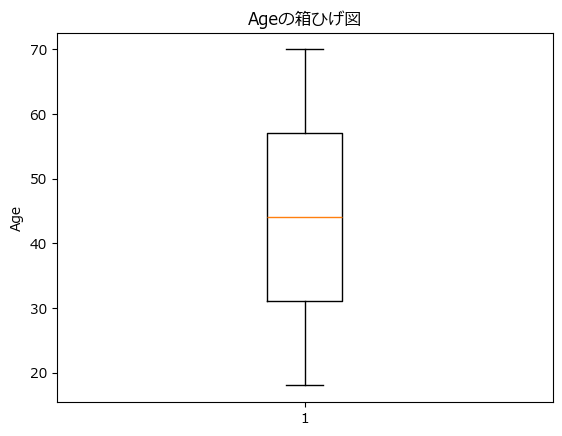

In [464]:
import matplotlib.pyplot as plt

plt.boxplot(df["Age"])
plt.title("Ageの箱ひげ図")
plt.ylabel("Age")
plt.show()


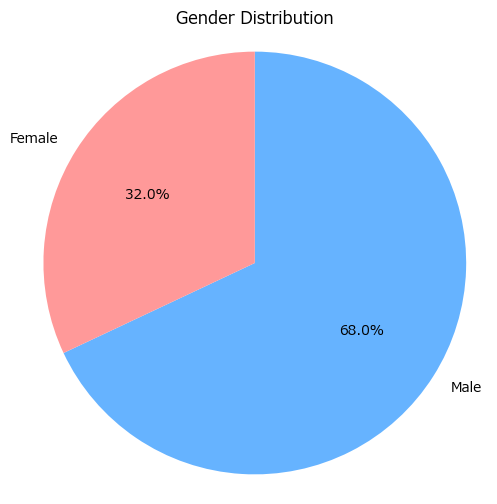

In [465]:
# 10色のカラーパレットを定義
COLOR_PALETTE = [
    "#66b3ff",  # ブルー
    "#ff9999",  # ピンク
    "#99ff99",  # グリーン
    "#ffcc99",  # オレンジ
    "#c2c2f0",  # ラベンダー
    "#ffb3e6",  # ライトピンク
    "#c2f0c2",  # ライトグリーン
    "#ff6666",  # レッド
    "#99ffff",  # アクア
    "#ffccff"   # ライトパープル
]


def create_pie(df, column, title, colors=None):
    data_count = df[column].value_counts()
    data_len = len(data_count.index)
    if colors is None:
        colors = COLOR_PALETTE[:data_len]

    # 円グラフの作成
    plt.figure(figsize=(6, 6))  # グラフのサイズを指定
    plt.pie(data_count, 
            labels=data_count.index,    # カウントされた性別をラベルとして使用
            colors=colors,
            autopct='%1.1f%%',             # パーセント表示
            startangle=90,                # 90度から開始
            counterclock=False)           # 時計回りに描画

    # 円グラフを円形に
    plt.axis('equal')

    # タイトルを追加
    plt.title(title)

    # グラフを表示
    plt.show()

colors = ['#66b3ff', '#ff9999']
title = 'Gender Distribution'
column = "Gender"
create_pie(df, column, title)

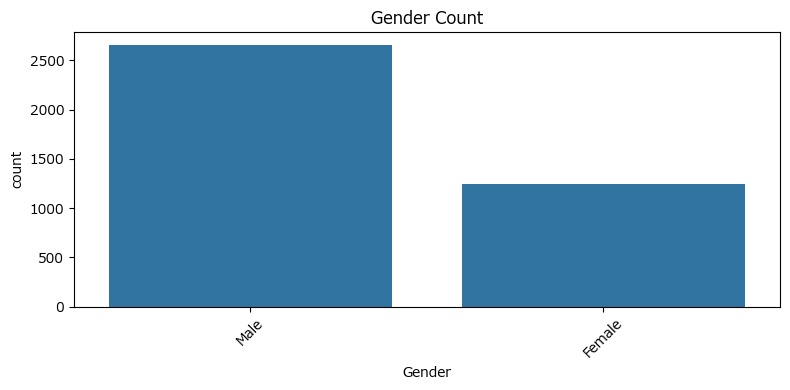

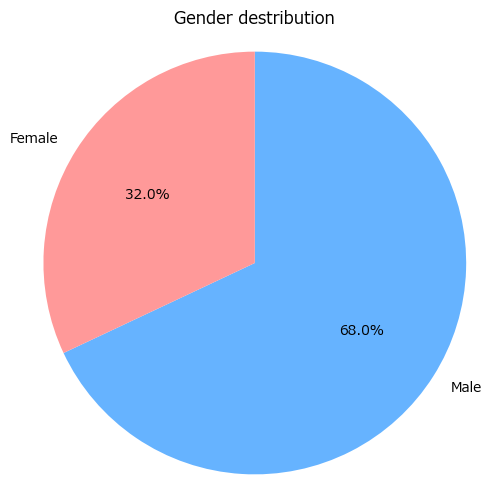

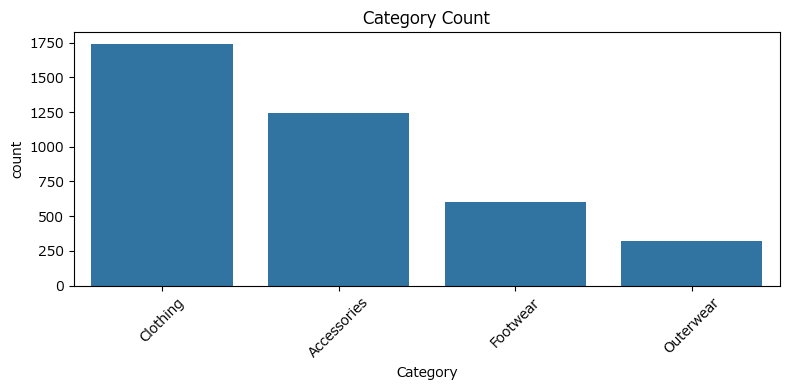

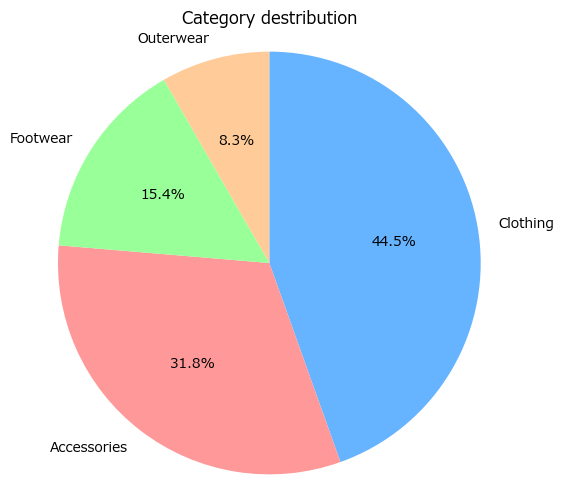

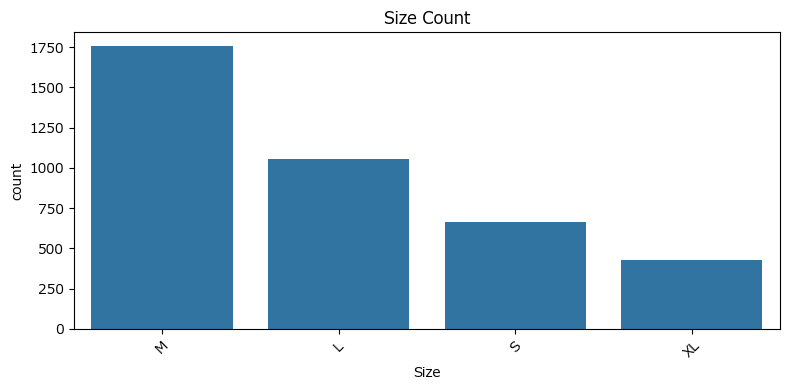

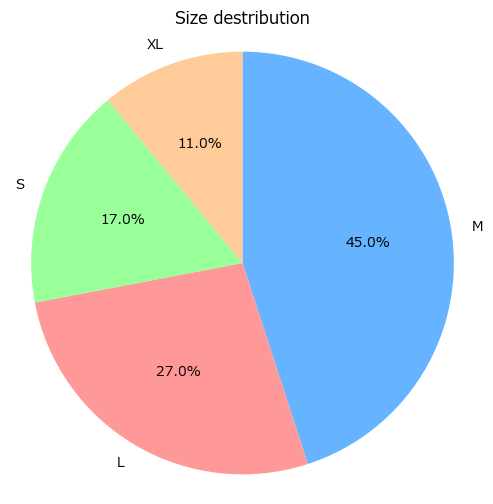

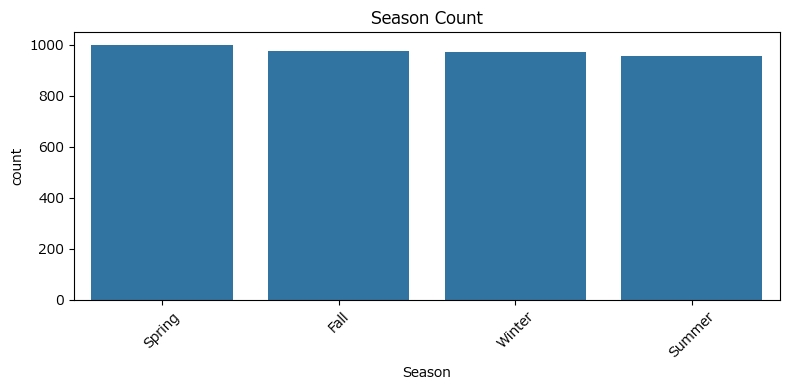

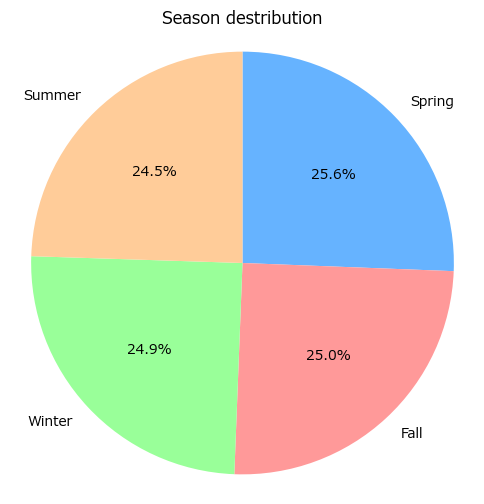

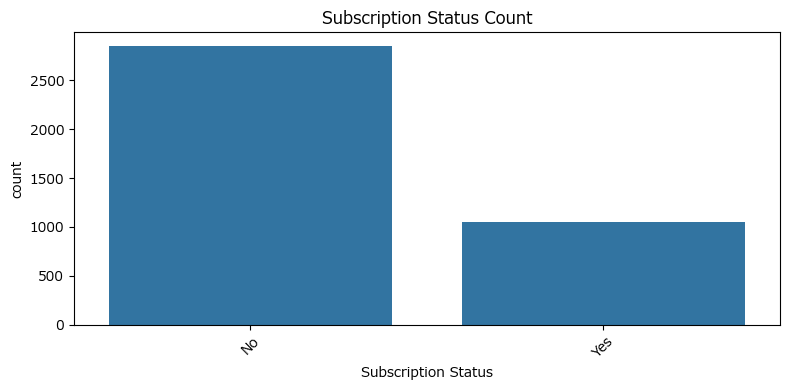

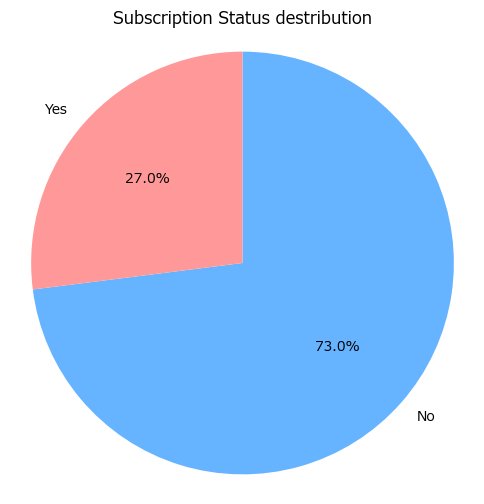

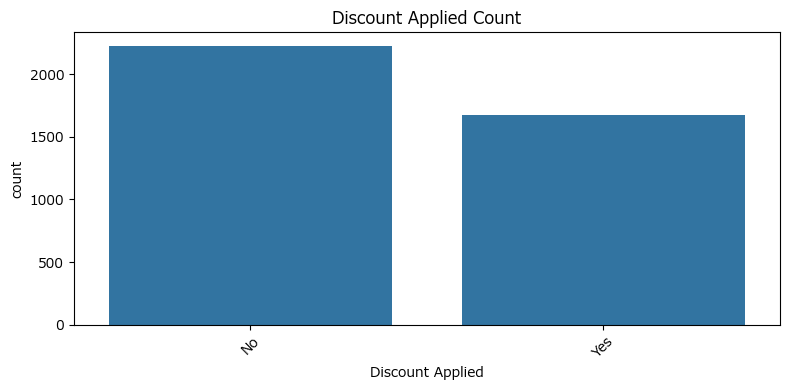

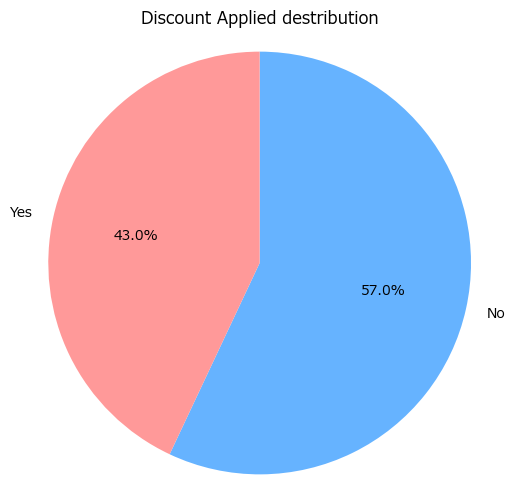

In [466]:
for column in ["Gender", "Category", "Size", "Season", "Subscription Status", "Discount Applied"]:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=column, order=df[column].value_counts().index)
    plt.title(f"{column} Count")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    create_pie(df, column, f"{column} destribution")

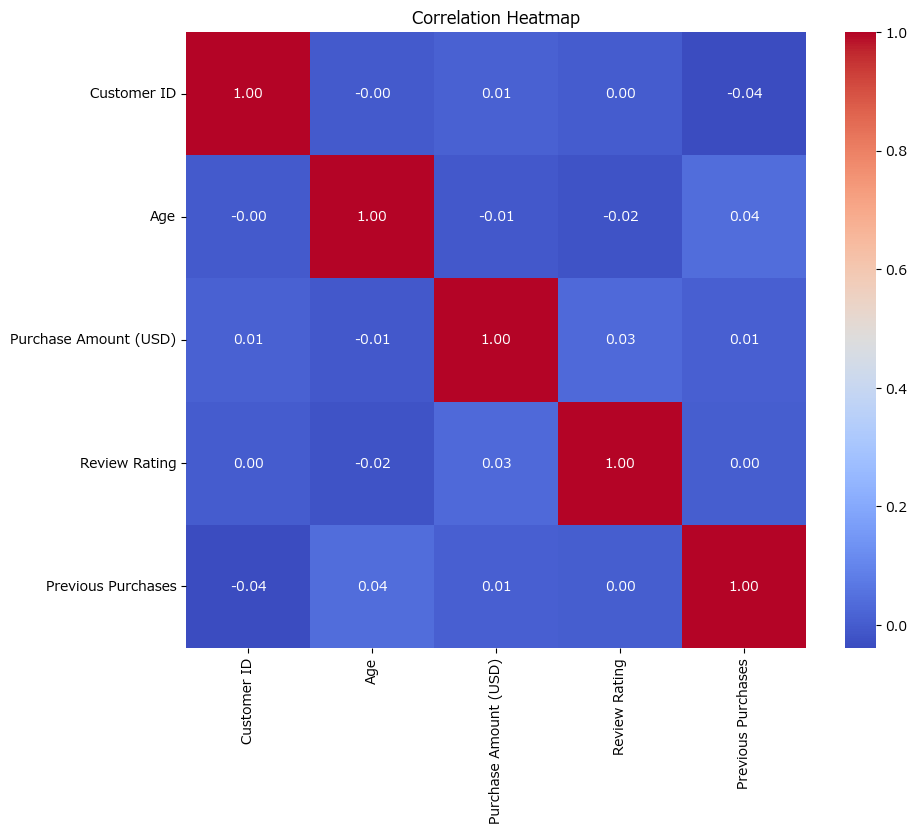

In [467]:
import seaborn as sns
import matplotlib.pyplot as plt

# とりあえず数値型だけ抜き出して相関係数を計算
corr = df.select_dtypes(include=['number']).corr()

# ヒートマップを描画
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()


In [468]:
# 数値型カラムを確認
print(df.select_dtypes(include=['number']).columns)


Index(['Customer ID', 'Age', 'Purchase Amount (USD)', 'Review Rating',
       'Previous Purchases'],
      dtype='object')


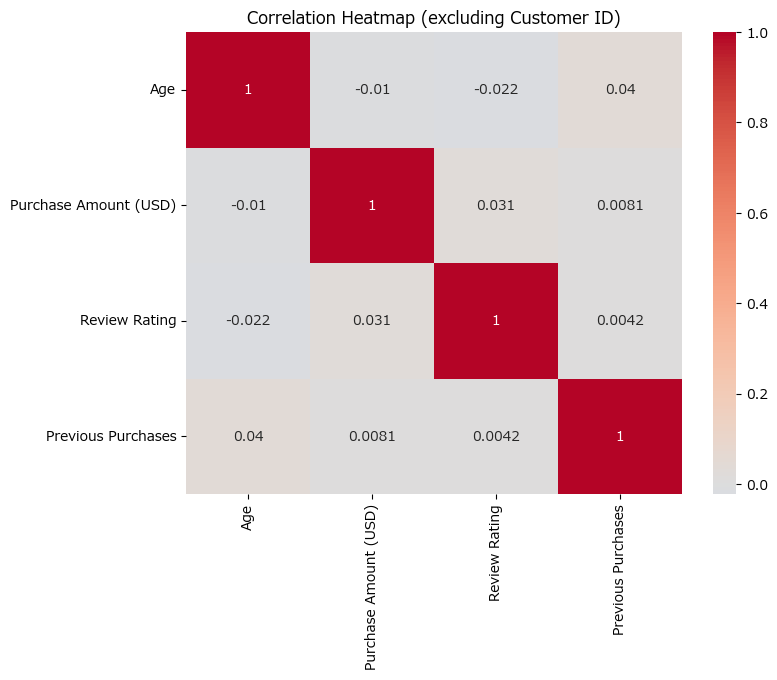

In [469]:
# Customer IDを除く
cols = ['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases']

# 相関行列を作成
corr = df[cols].corr()

# ヒートマップ作成
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (excluding Customer ID)')
plt.show()


In [470]:
def encode_columns_by_one_hot(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    """指定した複数カラムをワンホットエンコードする。

    Args:
        df (pd.DataFrame): 元のデータフレーム
        columns (list[str]): エンコードしたいカラム名のリスト

    Returns:
        pd.DataFrame: エンコード後のデータフレーム

    Raises:
        KeyError: 指定されたカラムが存在しない場合

    Example:
        df_encoded = encode_columns(df, ["Gender", "Category"])
    """
    missing_cols = [col for col in columns if col not in df.columns]
    if missing_cols:
        raise KeyError(f"存在しないカラムが指定されました: {missing_cols}")

    df_encoded = pd.get_dummies(df, columns=columns, prefix=columns, drop_first=False)
    return df_encoded



In [471]:
# まず不要なカラムをドロップ
df = df.drop(columns=["Promo Code Used"])

# 必要なカラムを一括エンコード
columns_to_encode = [
    "Gender", "Category", "Size", "Season",
    "Subscription Status", "Shipping Type",
    "Discount Applied", "Payment Method"
]
df_encoded = encode_columns_by_one_hot(df, columns_to_encode)

In [472]:
df_encoded.head()

,Customer ID,Age,Purchase Amount (USD),Location,Color,Review Rating,Previous Purchases,Frequency of Purchases,AgeGroup,PurchaseAmountGroup,...,Shipping Type_Standard,Shipping Type_Store Pickup,Discount Applied_No,Discount Applied_Yes,Payment Method_Bank Transfer,Payment Method_Cash,Payment Method_Credit Card,Payment Method_Debit Card,Payment Method_PayPal,Payment Method_Venmo
0,1,55,53,Kentucky,Gray,3.1,14,Fortnightly,50-59,Medium,...,False,False,False,True,False,False,False,False,False,True
1,2,19,64,Maine,Maroon,3.1,2,Fortnightly,18-29,Medium,...,False,False,False,True,False,True,False,False,False,False
2,3,50,73,Massachusetts,Maroon,3.1,23,Weekly,50-59,High,...,False,False,False,True,False,False,True,False,False,False
3,4,21,90,Rhode Island,Maroon,3.5,49,Weekly,18-29,Very High,...,False,False,False,True,False,False,False,False,True,False
4,5,45,49,Oregon,Turquoise,2.7,31,Annually,40-49,Low,...,False,False,False,True,False,False,False,False,True,False


In [473]:
df_encoded.groupby("Subscription Status_Yes").sum()

TypeError: category type does not support sum operations

In [ ]:
print(df_encoded.select_dtypes(include=['number', "bool"]).columns[1:])


Index(['Age', 'Purchase Amount (USD)', 'Review Rating', 'Previous Purchases',
       'Gender_Female', 'Gender_Male', 'Category_Accessories',
       'Category_Clothing', 'Category_Footwear', 'Category_Outerwear',
       'Size_L', 'Size_M', 'Size_S', 'Size_XL', 'Season_Fall', 'Season_Spring',
       'Season_Summer', 'Season_Winter', 'Subscription Status_No',
       'Subscription Status_Yes', 'Shipping Type_2-Day Shipping',
       'Shipping Type_Express', 'Shipping Type_Free Shipping',
       'Shipping Type_Next Day Air', 'Shipping Type_Standard',
       'Shipping Type_Store Pickup', 'Discount Applied_No',
       'Discount Applied_Yes', 'Payment Method_Bank Transfer',
       'Payment Method_Cash', 'Payment Method_Credit Card',
       'Payment Method_Debit Card', 'Payment Method_PayPal',
       'Payment Method_Venmo'],
      dtype='object')


In [ ]:
# ピアソン相関
corr_matrix = df[['Age', 'Purchase Amount (USD)']].corr(method='pearson')
print(corr_matrix)

# スピアマン相関（順位相関の場合）
corr_matrix_spearman = df[['Age', 'Purchase Amount (USD)']].corr(method='spearman')
print(corr_matrix_spearman)


                            Age  Purchase Amount (USD)
Age                    1.000000              -0.010424
Purchase Amount (USD) -0.010424               1.000000
                            Age  Purchase Amount (USD)
Age                    1.000000              -0.010445
Purchase Amount (USD) -0.010445               1.000000


In [ ]:
df["Item Purchased"].unique()

array(['Blouse', 'Sweater', 'Jeans', 'Sandals', 'Sneakers', 'Shirt',
       'Shorts', 'Coat', 'Handbag', 'Shoes', 'Dress', 'Skirt',
       'Sunglasses', 'Pants', 'Jacket', 'Hoodie', 'Jewelry', 'T-shirt',
       'Scarf', 'Hat', 'Socks', 'Backpack', 'Belt', 'Boots', 'Gloves'],
      dtype=object)

In [ ]:
df["Category"].unique()

array(['Clothing', 'Footwear', 'Outerwear', 'Accessories'], dtype=object)

In [ ]:
df["Previous Purchases"].unique()

array([14,  2, 23, 49, 31, 19,  8,  4, 26, 10, 37, 34, 44, 36, 17, 46, 50,
       22, 32, 40, 16, 13,  7, 41, 45, 38, 48, 18, 15, 25, 39, 35, 29, 21,
       43,  3,  5, 24, 42, 47, 28, 20, 33,  1,  9, 12, 27, 11, 30,  6])

In [ ]:


df = encode_columns(df, encoding_config)

In [ ]:
df["Gender"].unique()

array([0, 1])

In [ ]:
df["Size"].unique()

array([2, 0, 1, 3])

In [ ]:
def categorize_age_numeric(age: int) -> int:
    """年齢を10歳ごとのグループに数値で分類する

    Args:
        age (int): 年齢

    Returns:
        int: 年齢グループを表す数値（0:10代, 1:20代, ...）

    Raises:
        None

    Example:
        >>> categorize_age_numeric(25)
        1
    """
    if pd.isna(age):
        return -1  # 欠損値は -1（または別途管理）
    if age < 20:
        return 0
    elif age < 30:
        return 1
    elif age < 40:
        return 2
    elif age < 50:
        return 3
    elif age < 60:
        return 4
    else:
        return 5

df['Age Group'] = df['Age'].apply(categorize_age_numeric)


In [ ]:
df["Age Group"].value_counts()

Age Group
5    788
4    771
3    739
1    728
2    724
0    150
Name: count, dtype: int64

In [ ]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases,AgeGroup,Age Group
0,1,55,0,Blouse,0,53,Kentucky,2,Gray,3,3.1,1,Express,1,14,Venmo,Fortnightly,50-59,4
1,2,19,0,Sweater,0,64,Maine,2,Maroon,3,3.1,1,Express,1,2,Cash,Fortnightly,18-29,0
2,3,50,0,Jeans,0,73,Massachusetts,0,Maroon,0,3.1,1,Free Shipping,1,23,Credit Card,Weekly,50-59,4
3,4,21,0,Sandals,1,90,Rhode Island,1,Maroon,0,3.5,1,Next Day Air,1,49,PayPal,Weekly,18-29,1
4,5,45,0,Blouse,0,49,Oregon,1,Turquoise,0,2.7,1,Free Shipping,1,31,PayPal,Annually,40-49,3


In [ ]:
df["Location"].unique()

array(['Kentucky', 'Maine', 'Massachusetts', 'Rhode Island', 'Oregon',
       'Wyoming', 'Montana', 'Louisiana', 'West Virginia', 'Missouri',
       'Arkansas', 'Hawaii', 'Delaware', 'New Hampshire', 'New York',
       'Alabama', 'Mississippi', 'North Carolina', 'California',
       'Oklahoma', 'Florida', 'Texas', 'Nevada', 'Kansas', 'Colorado',
       'North Dakota', 'Illinois', 'Indiana', 'Arizona', 'Alaska',
       'Tennessee', 'Ohio', 'New Jersey', 'Maryland', 'Vermont',
       'New Mexico', 'South Carolina', 'Idaho', 'Pennsylvania',
       'Connecticut', 'Utah', 'Virginia', 'Georgia', 'Nebraska', 'Iowa',
       'South Dakota', 'Minnesota', 'Washington', 'Wisconsin', 'Michigan'],
      dtype=object)

In [ ]:
def encode_location(df: pd.DataFrame, region_mapping: dict) -> pd.DataFrame:
    def map_region(location: str) -> str:
        for region, states in region_mapping.items():
            if location in states:
                return region
        return 'Unknown'  # 万が一のため、該当しない州には 'Unknown' を設定
    
    df['Region'] = df['Location'].apply(map_region)
    return df


In [ ]:
region_mapping = {
    'Northeast': ['Maine', 'New Hampshire', 'Vermont', 'Massachusetts', 'Rhode Island', 'Connecticut', 'New York', 'New Jersey', 'Pennsylvania'],
    'Midwest': ['Ohio', 'Indiana', 'Illinois', 'Michigan', 'Wisconsin', 'Missouri', 'Minnesota', 'Iowa', 'Nebraska', 'Kansas', 'North Dakota', 'South Dakota'],
    'South': ['Delaware', 'Maryland', 'Virginia', 'North Carolina', 'South Carolina', 'Georgia', 'Florida', 'Alabama', 'Mississippi', 'Tennessee', 'Kentucky', 'Arkansas', 'Louisiana', 'Oklahoma', 'Texas', 'West Virginia'],
    'West': ['Montana', 'Wyoming', 'Colorado', 'Idaho', 'Nevada', 'Utah', 'Arizona', 'Washington', 'Oregon', 'California', 'Alaska', 'Hawaii', 'New Mexico']
}

df = encode_location(df, region_mapping)

In [ ]:
df["Color"].unique()

array(['Gray', 'Maroon', 'Turquoise', 'White', 'Charcoal', 'Silver',
       'Pink', 'Purple', 'Olive', 'Gold', 'Violet', 'Teal', 'Lavender',
       'Black', 'Green', 'Peach', 'Red', 'Cyan', 'Brown', 'Beige',
       'Orange', 'Indigo', 'Yellow', 'Magenta', 'Blue'], dtype=object)

In [ ]:
# 1. カラーごとの売上合計を計算
color_sales = df.groupby('Color')['Purchase Amount (USD)'].sum().reset_index()

# 2. カラーごとの売上平均を計算
color_avg_sales = df.groupby('Color')['Purchase Amount (USD)'].mean().reset_index()

# 3. 売上合計や平均を色ごとに並べて確認
color_sales = color_sales.sort_values('Purchase Amount (USD)', ascending=False)
color_avg_sales = color_avg_sales.sort_values('Purchase Amount (USD)', ascending=False)

# 結果を表示
print(color_sales)


        Color  Purchase Amount (USD)
8       Green                  11104
20       Teal                  10459
24     Yellow                  10308
13      Olive                  10292
5        Cyan                  10274
22     Violet                  10245
7        Gray                   9936
19     Silver                   9832
1       Black                   9753
12     Maroon                   9405
14     Orange                   9377
4    Charcoal                   9277
16       Pink                   9270
17     Purple                   9062
23      White                   8895
0       Beige                   8881
15      Peach                   8819
18        Red                   8779
10   Lavender                   8692
11    Magenta                   8684
2        Blue                   8657
6        Gold                   8419
3       Brown                   8328
9      Indigo                   8269
21  Turquoise                   8064


([<matplotlib.axis.XTick at 0x28c54b9c910>,
 [Text(0, 0, '10代'),
  Text(1, 0, '20代'),
  Text(2, 0, '30代'),
  Text(3, 0, '40代'),
  Text(4, 0, '50代'),
  Text(5, 0, 'シニア')])

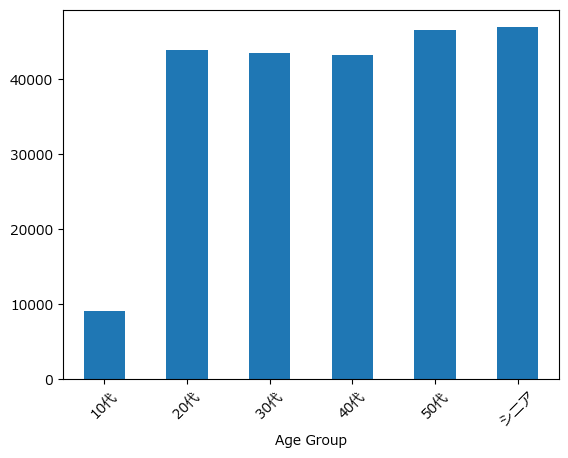

In [ ]:
age_group_df = df.groupby("Age Group")["Purchase Amount (USD)"].sum()
age_group = ["10代", "20代", "30代", "40代", "50代", "シニア"]

age_group_df.plot(kind="bar")
plt.xticks(ticks=range(len(age_group)), labels=age_group, rotation=45)



([<matplotlib.axis.XTick at 0x28c5445de50>,
 [Text(0, 0, '10代'),
  Text(1, 0, '20代'),
  Text(2, 0, '30代'),
  Text(3, 0, '40代'),
  Text(4, 0, '50代'),
  Text(5, 0, 'シニア')])

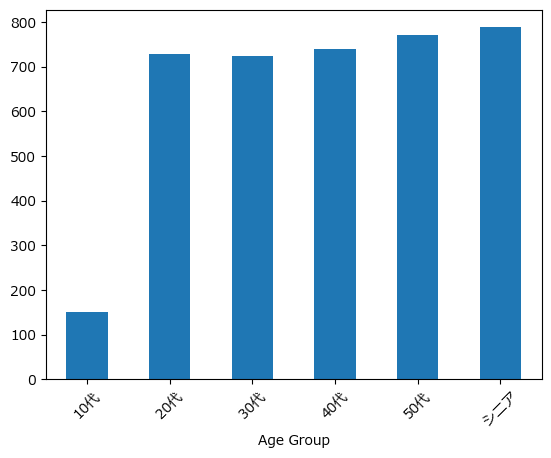

In [ ]:
df["Age Group"].value_counts().sort_index().plot(kind="bar")
plt.xticks(ticks=range(len(age_group)), labels=age_group, rotation=45)

In [ ]:
def group_graph(df, column, labels):
    group_df = df.groupby(column)["Purchase Amount (USD)"].sum()

    group_df.plot(kind="bar")
    plt.title(f"{column} 別売上(USD)")
    # plt.xticks(ticks=range(len(labels)), labels=labels, rotation=45)
    plt.show()


    df[column].value_counts().sort_index().plot(kind="bar")
    # plt.xticks(ticks=range(len(labels)), labels=labels, rotation=45)
    plt.title(f"{column} 別総数")
    plt.show()

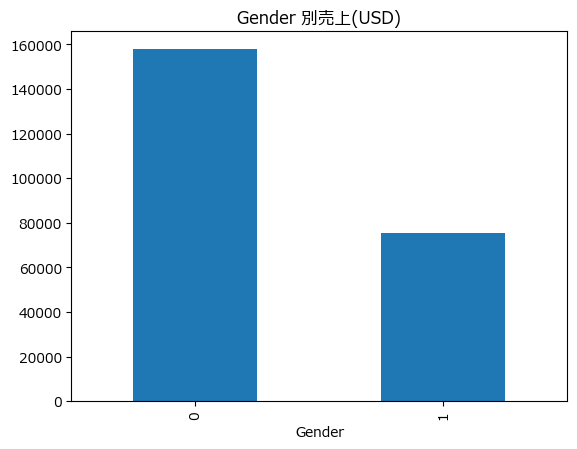

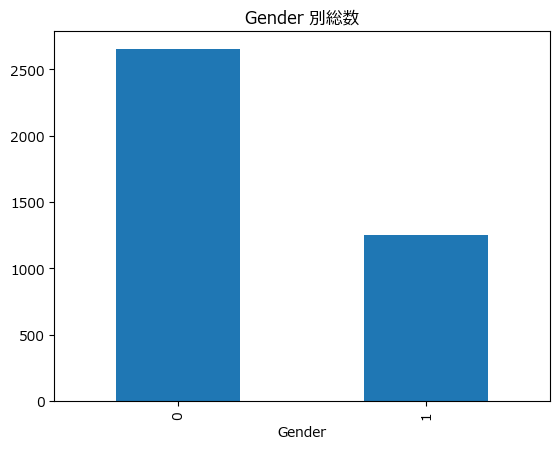

In [ ]:
group_graph(df, "Gender", labels["Gender"])

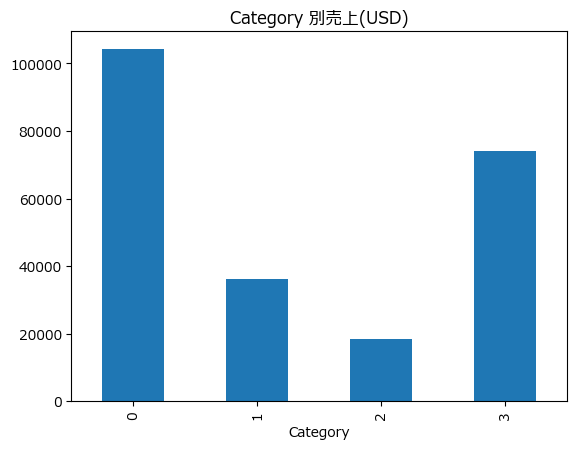

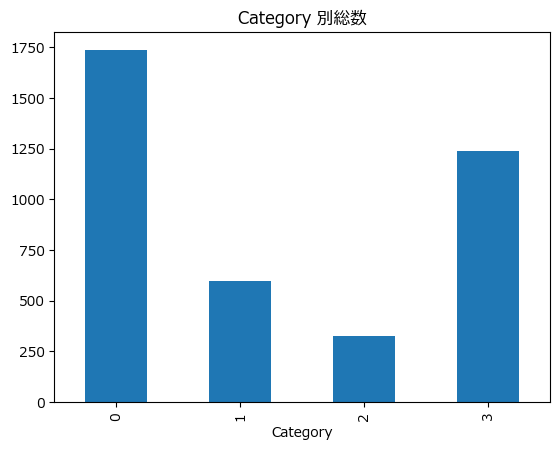

In [ ]:
# labels = df["Category"].value_counts()
# labels = ["Clothing", "Footwear", "Outerwear", "Accessories"]
group_graph(df, "Category", labels["Category"])

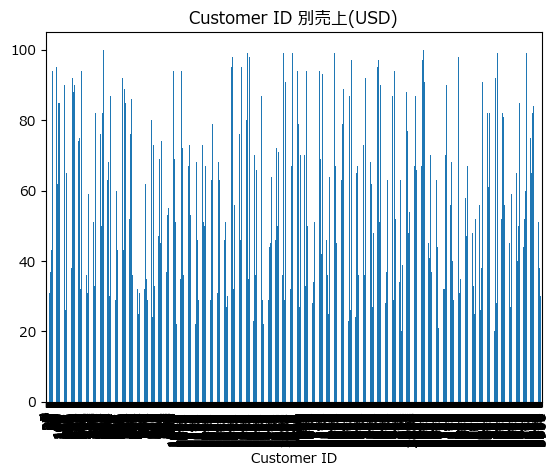

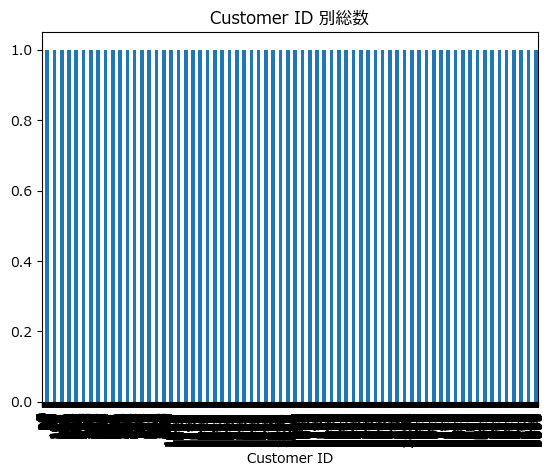

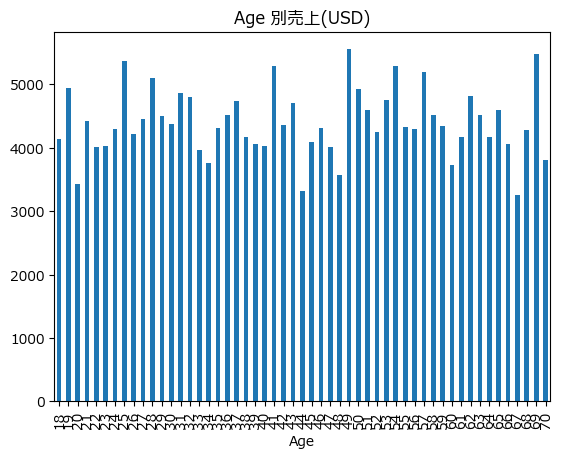

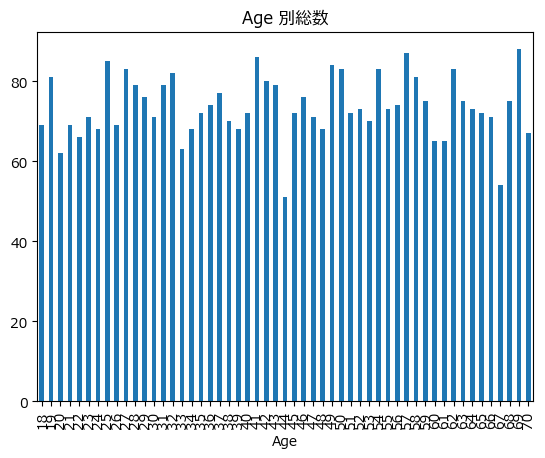

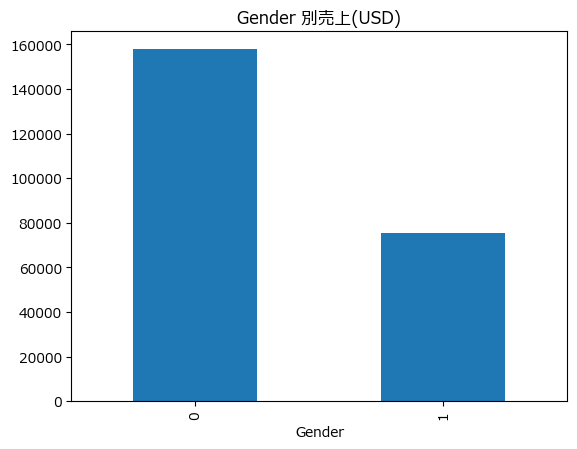

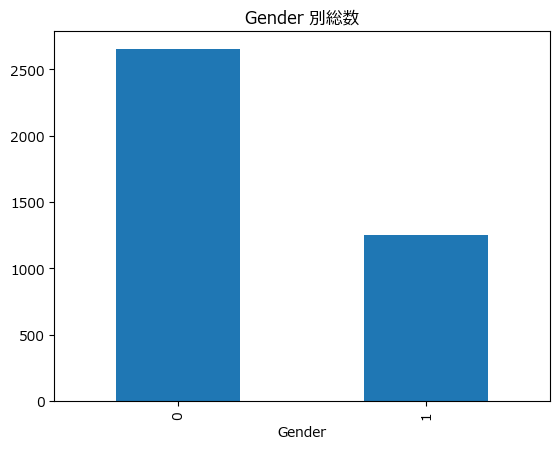

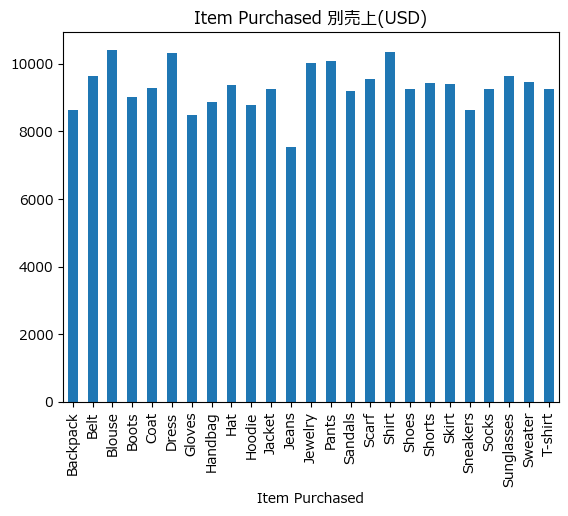

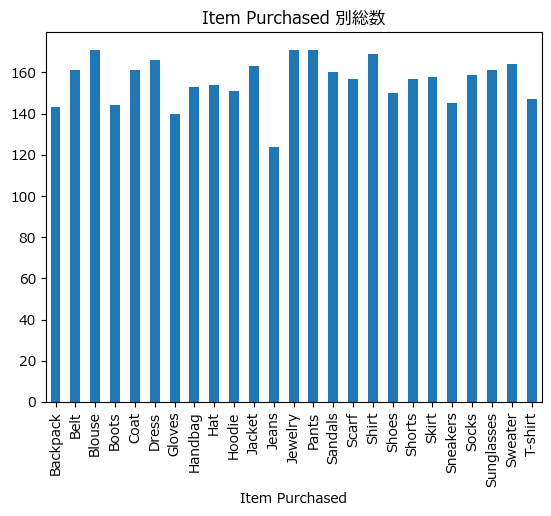

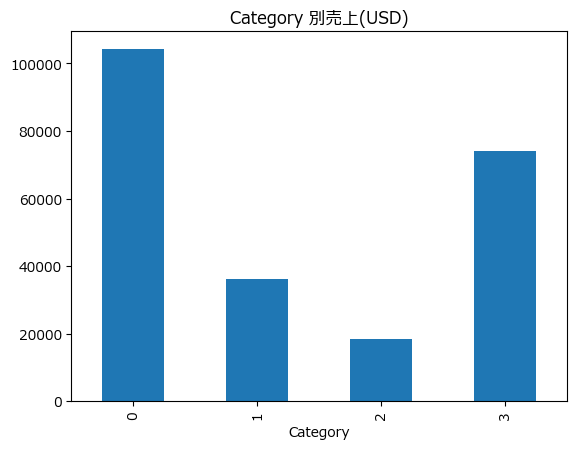

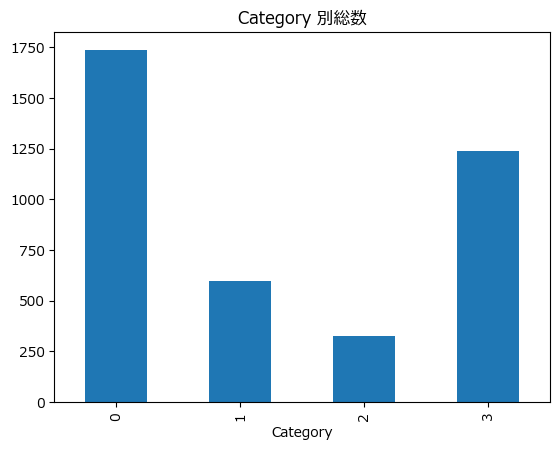

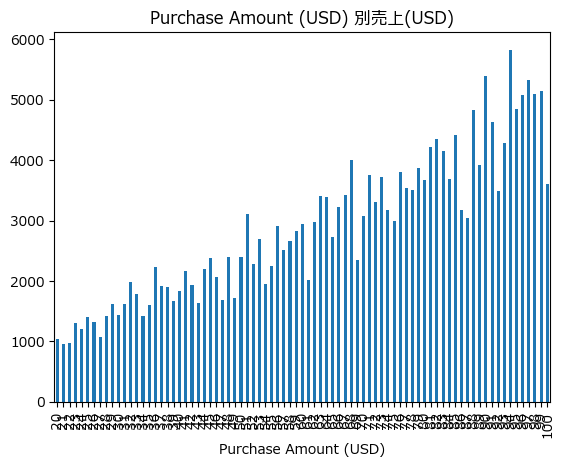

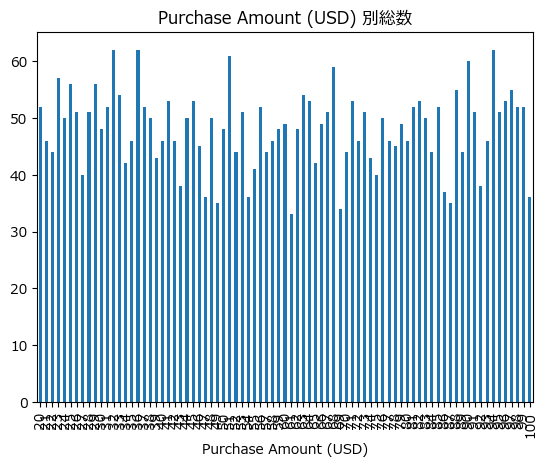

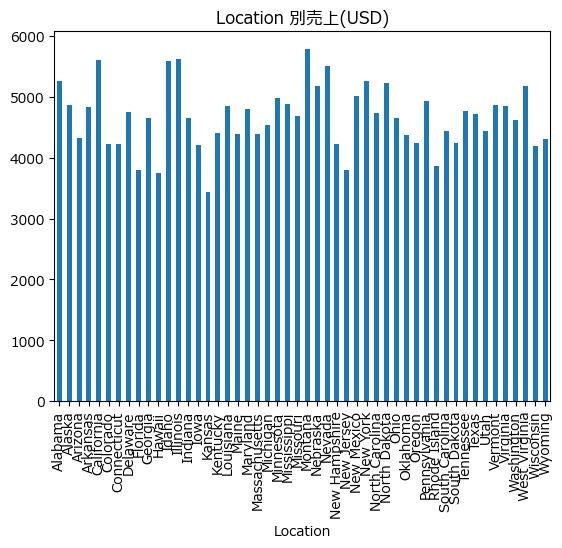

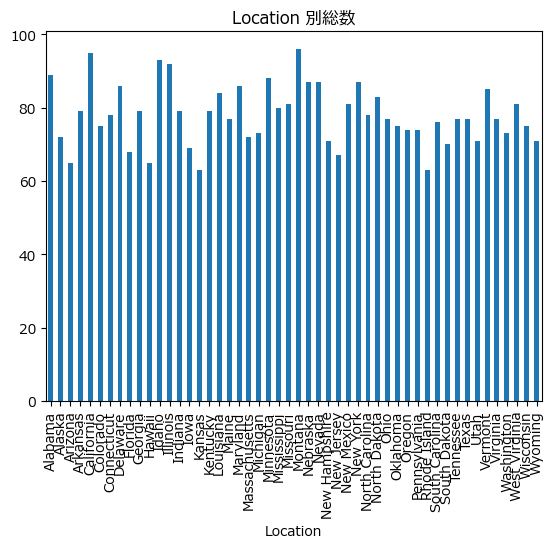

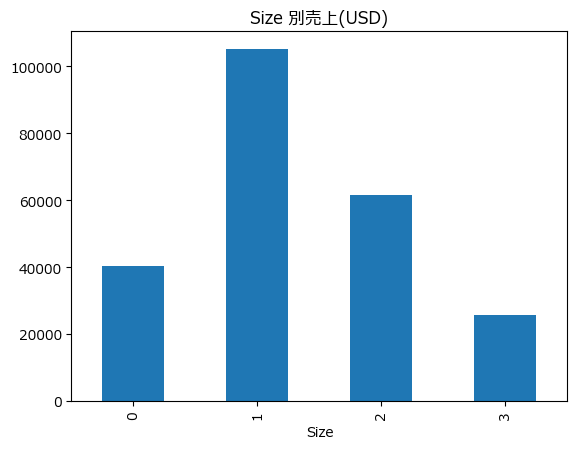

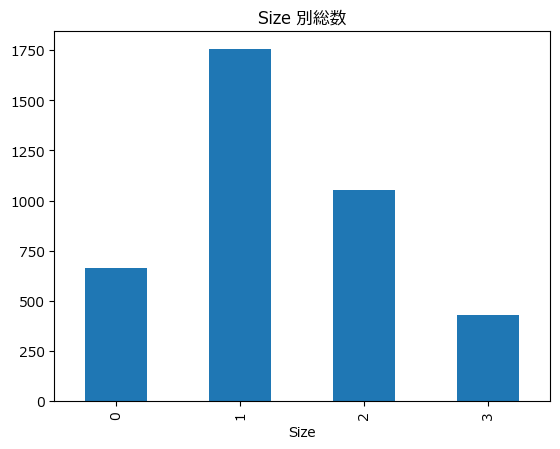

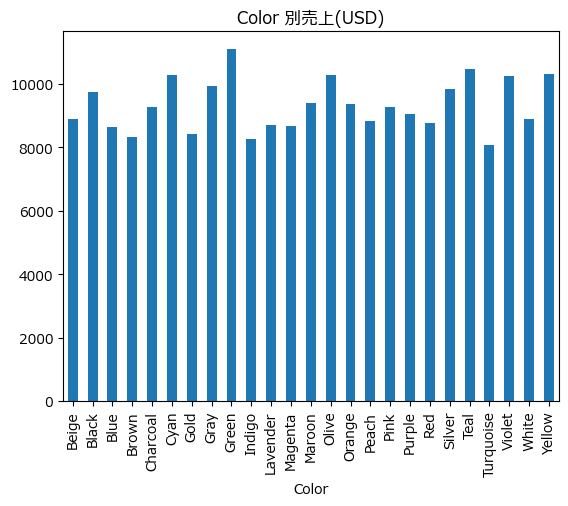

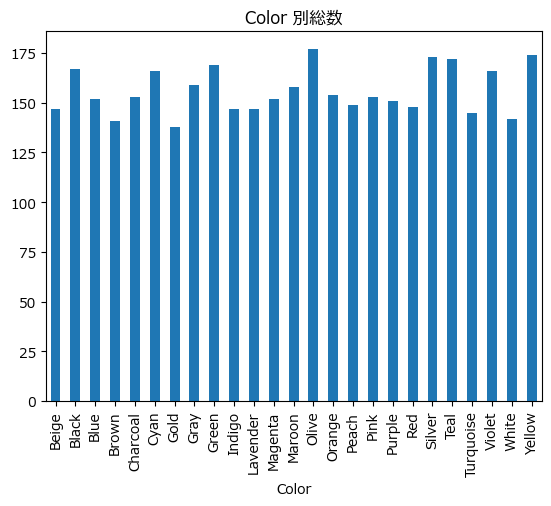

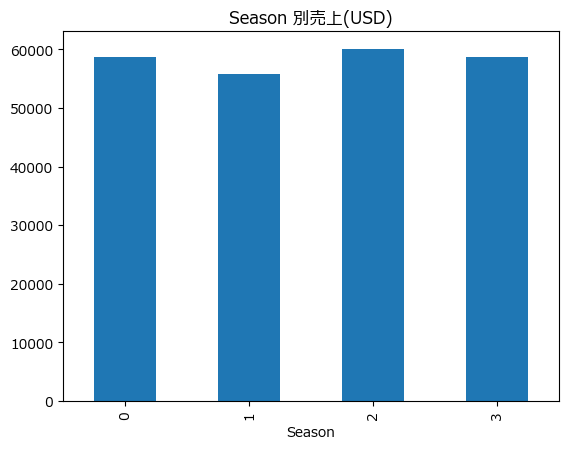

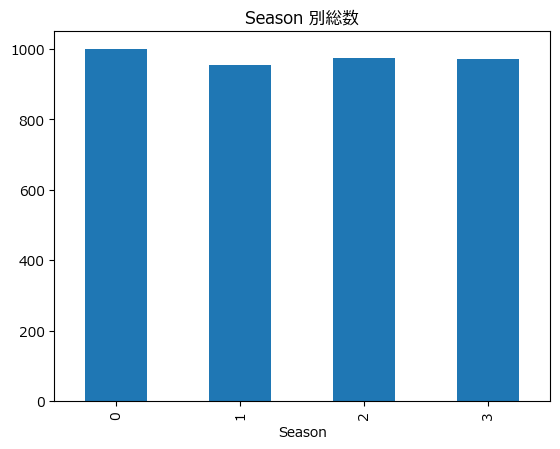

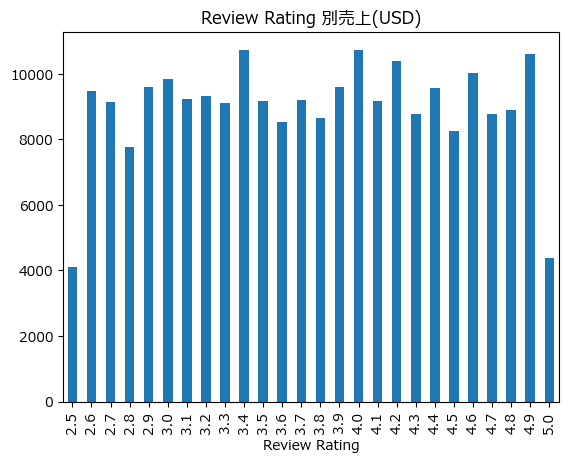

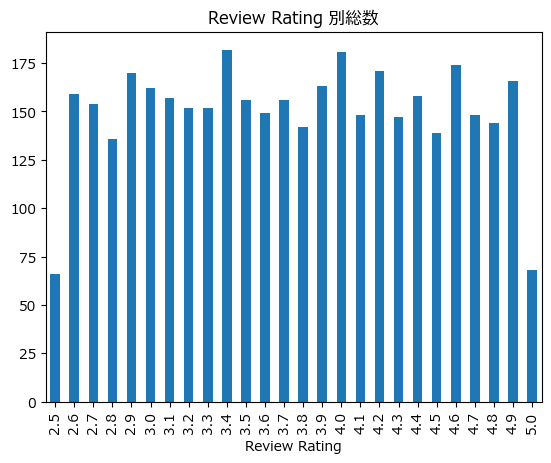

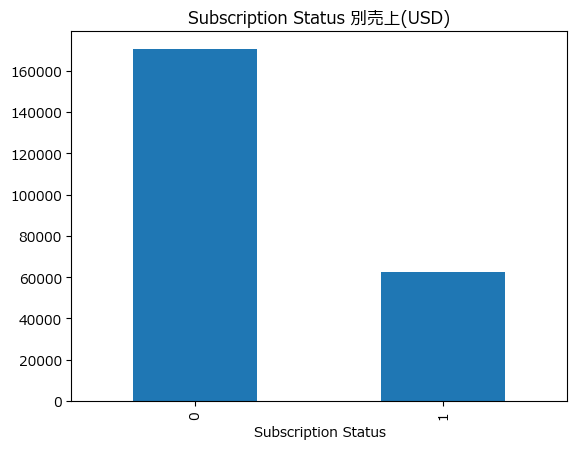

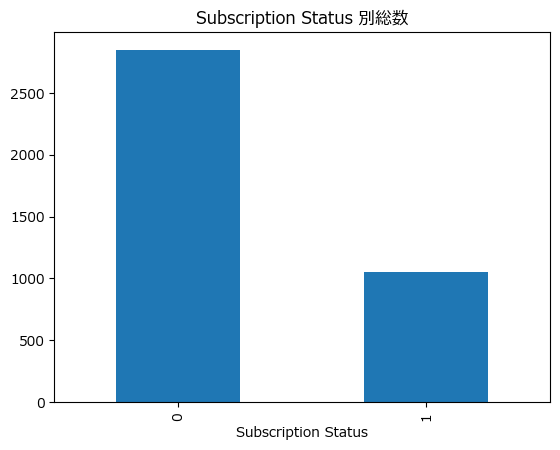

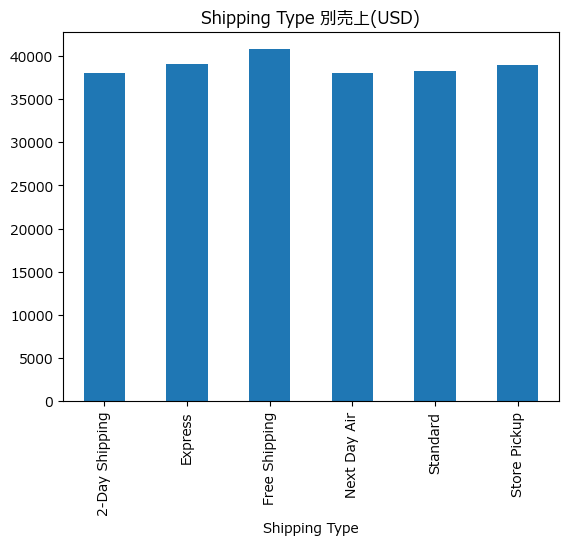

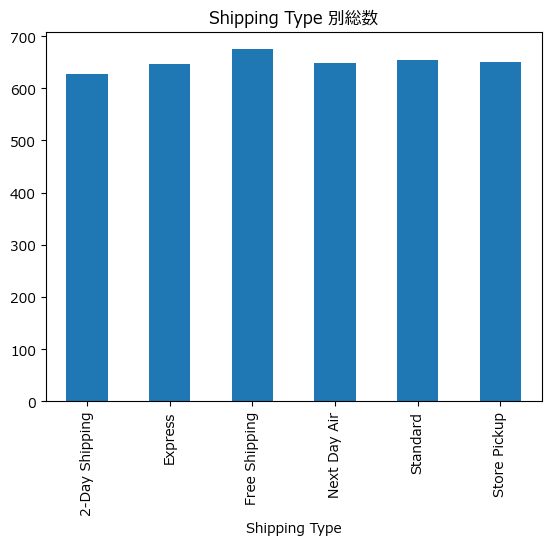

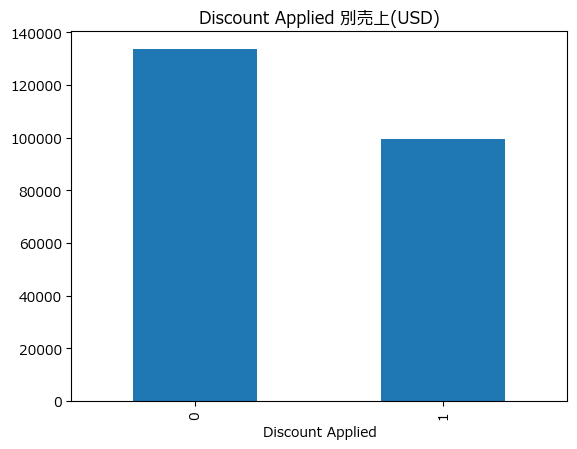

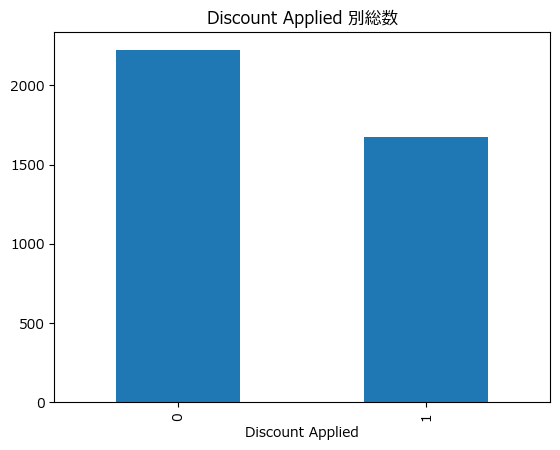

KeyError: 'Promo Code Used'

In [ ]:
for column in labels.keys():
    group_graph(df, column, labels[column])

In [ ]:
df["Frequency of Purchases"].unique()

array(['Fortnightly', 'Weekly', 'Annually', 'Quarterly', 'Bi-Weekly',
       'Monthly', 'Every 3 Months'], dtype=object)

In [ ]:
df.groupby("Frequency of Purchases")[["Purchase Amount (USD)", "Review Rating", "Previous Purchases"]].agg(["sum", "mean", "max", "min"])

Purchase Amount (USD)                      \
                                         sum       mean  max min   
Frequency of Purchases                                             
Annually                               34419  60.173077  100  20   
Bi-Weekly                              33200  60.694698  100  20   
Every 3 Months                         35088  60.082192  100  20   
Fortnightly                            32007  59.053506  100  20   
Monthly                                32810  59.330922  100  20   
Quarterly                              33771  59.984014  100  20   
Weekly                                 31786  58.972171  100  20   

                       Review Rating                     Previous Purchases  \
                                 sum      mean  max  min                sum   
Frequency of Purchases                                                        
Annually                      2148.4  3.755944  5.0  2.5              14049   
Bi-Weekly                     2027.7  3.706947  5.0  2.5              13559   
Every 3 Months                2200.1  3.767295  5.0  2.5              14577   
Fortnightly                   2035.3  3.755166  5.0  2.5              13697   
Monthly                       2088.3  3.776311  5.0  2.5              13979   
Quarterly                     2098.6  3.727531  5.0  2.5              15119   
Weekly                        2026.4  3.759555  5.0  2.5              13891   

                                           
                             mean max min  
Frequency of Purchases                     
Annually                24.561189  50   1  
Bi-Weekly               24.787934  50   1  
Every 3 Months          24.960616  50   1  
Fortnightly             25.271218  50   1  
Monthly                 25.278481  50   1  
Quarterly               26.854352  50   1  
Weekly                  25.771800  50   1